## Ищем аномалии в банковских транзакциях

### Окружение

Датасет: [Credit Card Fraud Detection](https://www.kaggle.com/mlg-ulb/creditcardfraud) — транзакции европейских держателей карт за двое суток. Задача: поиск аномалий.

Признаки анонимизированы: `V1`…`V28` — первые 28 главных компонент после PCA-преобразования исходных данных, о которых ничего не известно. В открытом виде остались только `Time`, `Amount` и метка `Class`.

In [1]:
%pip install -q numpy pandas scikit-learn scipy matplotlib seaborn


[notice] A new release of pip is available: 25.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Загрузка данных

In [2]:
from pathlib import Path
from urllib.request import urlretrieve

# Kaggle отдаёт файл только по токену. Зеркало Google — тот же файл побайтно
# (150 828 752 байта, полная точность значений), качается без регистрации.
URL = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

# Путь относительный: рабочая директория ядра — папка с ноутбуком.
DATA_PATH = Path("data") / "creditcard.csv"

if DATA_PATH.exists():
    print(f"Файл уже на месте: {DATA_PATH} ({DATA_PATH.stat().st_size / 1024 ** 2:.0f} МБ)")
else:
    DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    urlretrieve(URL, DATA_PATH)
    print(f"Скачано: {DATA_PATH} ({DATA_PATH.stat().st_size / 1024 ** 2:.0f} МБ)")

Файл уже на месте: data/creditcard.csv (144 МБ)


## EDA

### Первичный осмотр

In [3]:
import pandas as pd

df = pd.read_csv(DATA_PATH)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [5]:
# .T — иначе 31 колонка не читается по ширине.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


284 807 транзакций и 31 колонка: `Time`, `Amount`, 28 компонент и метка `Class`. Пропусков нет ни одного, все колонки числовые, поэтому `describe(include="str")` здесь неприменим.

Средние компонент — порядка 1e-15, то есть ноль: данные уже центрированы. `Time` и `Amount` из этого ряда выбиваются: у `Time` максимум 172 792, у `Amount` медиана 22,00 против максимума 25 691,16.

Метку дальше не трогаем. `Class` — это ответ, а в задаче поиска аномалий его нет, поэтому строить на нём разбивки значило бы подглядывать. Единственное, что из метки берём — насколько аномалия редка.

### Шаг 1. Насколько редка аномалия

Считаем, сколько в данных положительных примеров. От этого зависит, какие метрики вообще что-то показывают.

In [6]:
counts = df["Class"].value_counts()

print(f"нормальных транзакций : {counts[0]:7d}")
print(f"аномальных            : {counts[1]:7d}")
print(f"доля аномалий         : {counts[1] / len(df):9.4%}")
print(f"на 1000 транзакций    : {counts[1] / len(df) * 1000:9.2f}")
print(f"соотношение классов   : 1 к {counts[0] / counts[1]:.0f}")
print()

# Модель, всегда отвечающая "нормальная", не находит ни одной аномалии,
# но формально угадывает долю, равную доле большего класса.
print(f"accuracy у модели «всегда 0» : {counts[0] / len(df):.6f}")

нормальных транзакций :  284315
аномальных            :     492
доля аномалий         :   0.1727%
на 1000 транзакций    :      1.73
соотношение классов   : 1 к 578

accuracy у модели «всегда 0» : 0.998273


Аномалий 492 на 284 807 транзакций — 0,1727%, меньше двух на тысячу, соотношение 1 к 578.

Модель, которая всегда отвечает "нормальная транзакция", получает accuracy 0,998273 и не находит ни одной аномалии. Accuracy на этих данных неприменима. ROC-AUC тоже вводит в заблуждение: 284 315 отрицательных примеров дают такой запас по оси ложных срабатываний, что их доля остаётся низкой при любом пороге. Мерить надо precision и recall на редком классе.

### Шаг 2. Дубликаты строк

Ищем строки, у которых совпадают все 30 признаков. Для поиска аномалий это важнее обычного: копии одной точки создают локальное сгущение, а методы, основанные на плотности, ровно плотность и меряют.

In [7]:
FEATURES = [c for c in df.columns if c != "Class"]

# Размер каждой группы строк с полностью одинаковыми признаками.
sizes = df.groupby(FEATURES, observed=True).size()
repeated = sizes[sizes > 1]

# Лишние копии: всё, кроме первого вхождения каждой группы.
extra = df.duplicated(subset=FEATURES)

print(f"групп одинаковых строк      : {len(repeated):5d}")
print(f"всего строк в этих группах  : {int(repeated.sum()):5d}")
print(f"лишних копий                : {extra.sum():5d}   ({int(repeated.sum())} - {len(repeated)})")
print(f"самая большая группа        : {int(repeated.max()):5d} строк")
print()
print("сколько групп какого размера:")
for size, n in repeated.value_counts().sort_index().items():
    print(f"    по {size:2d} строк(и) : {n:4d} групп")

групп одинаковых строк      :   773
всего строк в этих группах  :  1854
лишних копий                :  1081   (1854 - 773)
самая большая группа        :    18 строк

сколько групп какого размера:
    по  2 строк(и) :  611 групп
    по  3 строк(и) :   66 групп
    по  4 строк(и) :   81 групп
    по  5 строк(и) :   10 групп
    по  6 строк(и) :    1 групп
    по  9 строк(и) :    2 групп
    по 18 строк(и) :    2 групп


Одинаковые строки есть: 773 группы, 1854 строки на всех. Если оставить по одной строке от группы, удалить надо 1854 − 773 = 1081.

Чаще всего повтор двойной (611 групп), но есть и две группы по 18 строк. В самой большой все 18 строк идут подряд, с одинаковым `Time` — совпадает даже секунда. Значит это не разные похожие транзакции, а одна запись, продублированная в файле.

### Шаг 3. `Time` и `Amount` — единственные не-PCA признаки

Только эти две колонки остались в исходном виде и что-то значат сами по себе. Смотрим гистограммы и описательные статистики.

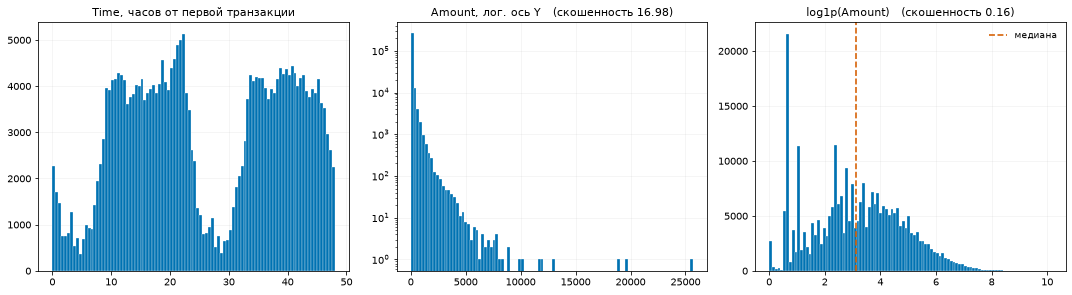

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew

# GitHub не отрисовывает ноутбуки тяжелее 1 МБ, а картинки в base64 — почти весь вес.
plt.rcParams["figure.dpi"] = 72

# Цвета Okabe-Ito: различимы при дальтонизме и в чёрно-белой печати.
COLOR_MAIN = "#0072B2"
COLOR_REF = "#D55E00"

log_amount = np.log1p(df["Amount"])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# Часы нагляднее секунд: сразу видно, есть ли суточный цикл.
axes[0].hist(df["Time"] / 3600, bins=96, color=COLOR_MAIN, edgecolor="white", linewidth=0.3)
axes[0].set_title("Time, часов от первой транзакции", fontsize=11)

# По линейной оси видна одна полоса у нуля — весь вес в первых процентах шкалы.
axes[1].hist(df["Amount"], bins=100, color=COLOR_MAIN, edgecolor="white", linewidth=0.3)
axes[1].set_yscale("log")
axes[1].set_title(f"Amount, лог. ось Y   (скошенность {skew(df['Amount']):.2f})", fontsize=11)

axes[2].hist(log_amount, bins=100, color=COLOR_MAIN, edgecolor="white", linewidth=0.3)
axes[2].axvline(log_amount.median(), color=COLOR_REF, linestyle="--", linewidth=1.6, label="медиана")
axes[2].set_title(f"log1p(Amount)   (скошенность {skew(log_amount):.2f})", fontsize=11)
axes[2].legend(frameon=False, fontsize=9)

for ax in axes:
    ax.grid(alpha=0.25, linewidth=0.5)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [9]:
a = df["Amount"]
z = (a - a.mean()) / a.std()

print(f"Time: от {df['Time'].min():.0f} до {df['Time'].max():.0f} с = {df['Time'].max() / 3600:.0f} ч ровно")
print(f"строки упорядочены по времени : {df['Time'].is_monotonic_increasing}")
print()
print(f"Amount: медиана {a.median():.2f}, среднее {a.mean():.2f}, максимум {a.max():.2f}")
print(f"скошенность {skew(a):.2f}, |z| > 3 у {(z.abs() > 3).sum()} строк, максимум {z.max():.0f} сигм")
print(f"нулевых сумм {(a == 0).sum()}")
print()

# Time отсчитывается от первой транзакции, поэтому сутки отсчитываем от неё же.
hour = (df["Time"] // 3600) % 24
by_hour = hour.value_counts().sort_index()
night = hour.between(1, 5)

print(f"самый тихий час : {int(by_hour.idxmin()):2d}, транзакций {by_hour.min():6d}")
print(f"самый плотный   : {int(by_hour.idxmax()):2d}, транзакций {by_hour.max():6d}")
print(f"отношение       : {by_hour.max() / by_hour.min():6.1f}")
print(f"часы 1—5 дают   : {night.mean():6.1%} всех транзакций")

Time: от 0 до 172792 с = 48 ч ровно
строки упорядочены по времени : True

Amount: медиана 22.00, среднее 88.35, максимум 25691.16
скошенность 16.98, |z| > 3 у 4076 строк, максимум 102 сигм
нулевых сумм 1825

самый тихий час :  4, транзакций   2209
самый плотный   : 21, транзакций  17703
отношение       :    8.0
часы 1—5 дают   :   5.7% всех транзакций


`Time` — секунды от первой транзакции, ровно 172 792, ровно 48 часов. Строки упорядочены по времени, то есть это не свойство транзакции, а её номер в очереди. Само число "секунда 94 814" ни о чём не говорит, а вот час суток — говорит: на гистограмме два провала, в четвёртом часу 2209 транзакций против 17 703 в двадцать первом, разница в 8 раз. На часы с первого по пятый приходится 5,7% всех транзакций.

`Amount` скошен на 16,98, за тремя сигмами 4076 строк, максимум — 102 сигмы. `log1p` убирает хвост целиком: скошенность падает до 0,16. Отдельно стоят 1825 нулевых сумм — на гистограмме это столбик в нуле, который логарифм никуда не денет.

### Шаг 4. Правда ли `V1`…`V28` — главные компоненты

У главных компонент попарные корреляции равны нулю, средние равны нулю, а дисперсии убывают от первой к последней.

Матрицу строим по всем 30 признакам, вместе с `Time` и `Amount`. Если взять только блок компонент, картинка окажется пустой и ничего не покажет. И считаем двумя способами: Пирсон ловит линейную связь, Спирмен — любую монотонную. PCA убирает первую, про вторую он ничего не обещает.

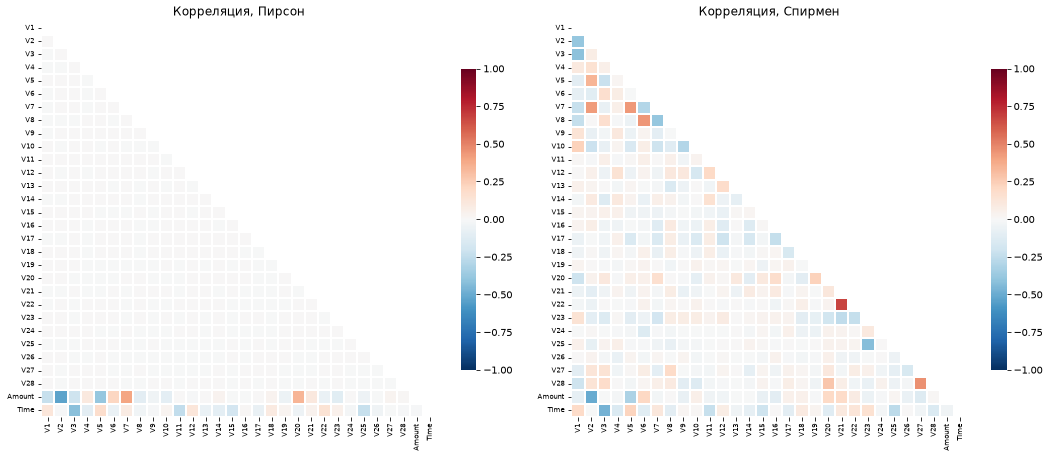

In [10]:
import seaborn as sns

V = [f"V{i}" for i in range(1, 29)]
ALL_COLS = V + ["Amount", "Time"]

pearson = df[ALL_COLS].corr()
spearman = df[ALL_COLS].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(15, 6.4))
for ax, m, name in zip(axes, [pearson, spearman], ["Пирсон", "Спирмен"]):
    # Прячем диагональ и верх: единицы на диагонали смысла не несут, но красятся ярче всего.
    mask = np.triu(np.ones_like(m, dtype=bool))
    sns.heatmap(m, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                square=True, linewidths=0.2, cbar_kws={"shrink": 0.7},
                xticklabels=True, yticklabels=True, ax=ax)
    ax.tick_params(labelsize=7)
    ax.set_title(f"Корреляция, {name}", fontsize=12)

plt.tight_layout()
plt.show()

In [11]:
def off_diagonal(matrix, cols):
    """Значения матрицы корреляций между перечисленными колонками, кроме диагонали."""
    block = matrix.loc[cols, cols].values
    return block[~np.eye(len(cols), dtype=bool)]

var = df[V].var()

print(f"максимум |Пирсон|  между компонентами : {np.abs(off_diagonal(pearson, V)).max():.2e}")
print(f"максимум |Спирмен| между компонентами : {np.abs(off_diagonal(spearman, V)).max():.2f}")
print(f"максимум |среднего| компоненты        : {df[V].mean().abs().max():.2e}")
print(f"дисперсии убывают монотонно           : {bool((var.diff().dropna() < 0).all())}")
print(f"дисперсия V1 против V28               : {var.iloc[0]:.3f} против {var.iloc[-1]:.3f}")
print()

HIGH_CORR = 0.6
for m, name in [(pearson, "Пирсону"), (spearman, "Спирмену")]:
    block = m.loc[V, V]
    pairs = [(a, b, block.loc[a, b]) for i, a in enumerate(V) for b in V[i + 1:]
             if abs(block.loc[a, b]) > HIGH_CORR]
    print(f"пар компонент с |corr| > {HIGH_CORR} по {name:9}: {len(pairs)}")
    for a, b, r in sorted(pairs, key=lambda t: -abs(t[2]))[:3]:
        print(f"    {a} ~ {b} : {r:.3f}")
print()

# Time и Amount в PCA не входили, поэтому с компонентами связь у них быть может.
print(f"максимум |Пирсон| компонент с Amount : {pearson.loc[V, 'Amount'].abs().max():.3f}"
      f"  ({pearson.loc[V, 'Amount'].abs().idxmax()})")
print(f"максимум |Пирсон| компонент с Time   : {pearson.loc[V, 'Time'].abs().max():.3f}"
      f"  ({pearson.loc[V, 'Time'].abs().idxmax()})")

максимум |Пирсон|  между компонентами : 2.32e-14
максимум |Спирмен| между компонентами : 0.68
максимум |среднего| компоненты        : 4.87e-15
дисперсии убывают монотонно           : True
дисперсия V1 против V28               : 3.836 против 0.109

пар компонент с |corr| > 0.6 по Пирсону  : 0
пар компонент с |corr| > 0.6 по Спирмену : 1
    V21 ~ V22 : 0.677

максимум |Пирсон| компонент с Amount : 0.531  (V2)
максимум |Пирсон| компонент с Time   : 0.420  (V3)


In [12]:
stds = df[V + ["Amount", "Time"]].std()

print(f"{'признак':10} {'std':>12}")
for c in ["V1", "V14", "V28", "Amount", "Time"]:
    print(f"{c:10} {stds[c]:12.2f}")
print()
print(f"отношение max/min std среди 28 компонент    : {stds[V].max() / stds[V].min():12.2f}")
print(f"отношение max/min std среди всех 30         : {stds.max() / stds.min():12.0f}")
print(f"то же в квадратах (так входит в расстояние) : {(stds.max() / stds.min()) ** 2:12.2e}")

признак             std
V1                 1.96
V14                0.96
V28                0.33
Amount           250.12
Time           47488.15

отношение max/min std среди 28 компонент    :         5.93
отношение max/min std среди всех 30         :       143867
то же в квадратах (так входит в расстояние) :     2.07e+10


Проверка сходится. По Пирсону максимум вне диагонали — 2,32e-14, машинный ноль. Средние компонент порядка 1e-15, дисперсии убывают строго монотонно от 3,836 у `V1` до 0,109 у `V28`. Это `V1`…`V28` и есть главные компоненты.

Весь левый треугольник блока компонент на heatmap белый - компоненты ортогональны по построению, нулевая корреляция гарантирована заранее.

Спирмен показывает другое. Правая панель уже не белая: между компонентами видна структура, максимум 0,677 у пары `V21`~`V22`. Пар выше 0,6 по Спирмену одна, по Пирсону — ни одной. Связь между компонентами есть, просто она не линейная, а PCA убирает только линейную.

Цветное на heatmap — две последних строки. `Amount` и `Time` в PCA не входили, поэтому связь с компонентами у них быть может, и она есть: `V2`~`Amount` = −0,531, `V3`~`Time` = 0,420.

Между собой компоненты различаются по масштабу всего в 5,93 раза, и это не разные единицы измерения, а разная доля объяснённой дисперсии. Приводить их к единичной дисперсии нельзя: это стёрло бы информацию о том, какая компонента главнее.

`Time` и `Amount` в общий ряд не встраиваются: стандартные отклонения 47 488 и 250 против 0,33…1,96 у компонент. Отношение по всем 30 признакам 143 867, в квадратах 2,07e+10. В любом методе, считающем расстояния, `Time` перекроет собой всё остальное.

Попарная корреляция говорит про одну компоненту за раз. Но `Time` и `Amount` могут быть размазаны сразу по нескольким, и тогда добавлять их к компонентам — значит считать одно и то же дважды. Проверяем, сколько от каждой восстанавливается по всем 28 сразу.

In [13]:
from sklearn.linear_model import LinearRegression

# R^2 линейной регрессии на 28 компонент: доля вариации, которую они уже содержат.
targets = {"Amount": df["Amount"],
           "log1p(Amount)": log_amount,
           "Time": df["Time"],
           "час суток": (df["Time"] // 3600) % 24}

print(f"{'величина':16} {'R^2 по V1...V28':>16}")
for name, y in targets.items():
    print(f"{name:16} {LinearRegression().fit(df[V], y).score(df[V], y):16.4f}")

величина          R^2 по V1...V28
Amount                     0.9175
log1p(Amount)              0.3916
Time                       0.4680
час суток                  0.2634


R² = 0,918 у сырой суммы выглядит так, будто компоненты её уже содержат.

### Шаг 5. Гистограммы компонент

Смотрим форму всех 28 распределений сразу. Нужно понять, похожи ли они на гауссовы: часть методов поиска аномалий считает удалённость от центра в предположении нормальности, и если оно не выполняется, хвост нормальных данных будет выглядеть аномальным.

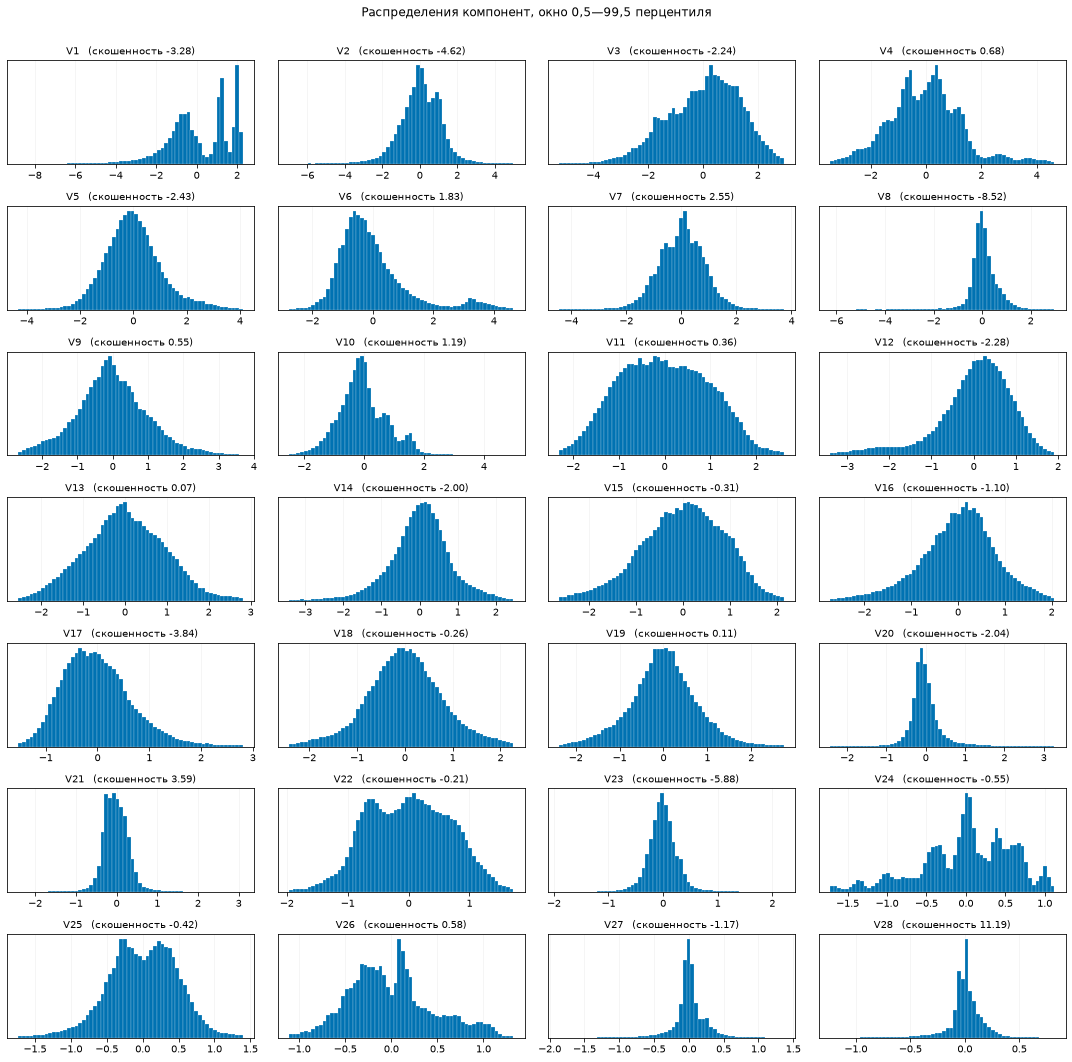

In [15]:
fig, axes = plt.subplots(7, 4, figsize=(15, 15))
for ax, c in zip(axes.ravel(), V):
    # Хвосты тяжёлые (до 100 сигм), поэтому показываем окно, а не всю ось:
    # иначе в кадре одна полоса в центре и пустое поле по краям.
    lo, hi = np.percentile(df[c], [0.5, 99.5])
    # range вместо clip: то, что не влезло, не рисуется, а не сваливается в крайний бин.
    ax.hist(df[c], bins=60, range=(lo, hi), color=COLOR_MAIN,
            edgecolor="white", linewidth=0.2)
    ax.set_title(f"{c}   (скошенность {skew(df[c]):.2f})", fontsize=10)
    ax.set_yticks([])
    ax.grid(alpha=0.25, linewidth=0.5)
    ax.set_axisbelow(True)

fig.suptitle("Распределения компонент, окно 0,5—99,5 перцентиля", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.975])
plt.show()

In [16]:
from scipy.stats import kurtosis

# У гауссова распределения скошенность 0, эксцесс 0, за тремя сигмами 0,27% точек.
z_all = (df[V] - df[V].mean()) / df[V].std()
outside = (z_all.abs() > 3).mean()
sk = df[V].apply(skew)
ku = pd.Series(kurtosis(df[V]), index=V)

print(f"{'компонента':11} {'скошенность':>12} {'эксцесс':>9} {'|z| > 3':>9}")
for c in ku.sort_values(ascending=False).index[:5]:
    print(f"{c:11} {sk[c]:12.2f} {ku[c]:9.0f} {outside[c]:9.2%}")
print(f"{'...':>11}")
for c in ku.sort_values(ascending=False).index[-3:]:
    print(f"{c:11} {sk[c]:12.2f} {ku[c]:9.0f} {outside[c]:9.2%}")
print()
print(f"компонент с |скошенностью| > 1 : {int((sk.abs() > 1).sum()):3d} из 28")
print(f"компонент с эксцессом > 3      : {int((ku > 3).sum()):3d} из 28")
print(f"доля точек за 3 сигмами        : от {outside.min():.2%} до {outside.max():.2%}"
      f"  (у гаусса 0,27%)")

компонента   скошенность   эксцесс   |z| > 3
V28                11.19       933     1.15%
V23                -5.88       440     1.18%
V7                  2.55       406     1.19%
V20                -2.04       271     1.63%
V27                -1.17       245     1.68%
        ...
V24                -0.55         1     0.23%
V15                -0.31         0     0.44%
V13                 0.07         0     0.42%

компонент с |скошенностью| > 1 :  17 из 28
компонент с эксцессом > 3      :  19 из 28
доля точек за 3 сигмами        : от 0.23% до 1.68%  (у гаусса 0,27%)


Гауссовыми компоненты не являются. У 17 из 28 скошенность по модулю больше единицы, у 19 эксцесс больше трёх. Крайний случай — `V28`: скошенность 11,19 и эксцесс 933 при гауссовых нулях.

За тремя сигмами лежит от 0,23% точек (`V24`) до 1,68% (`V27`) — у гаусса там 0,27%. То есть у большинства компонент далёких точек в разы больше, чем предполагает нормальное распределение, и метод, объявляющий выбросом всё дальше трёх сигм, наберёт их тысячами.

На гистограммах это видно как узкий острый пик вместо колокола: у `V28`, `V23`, `V27`, `V20`, `V8` почти вся масса стоит в одном-двух бинах. На колокол похожи только `V13`, `V15` и `V19`. Остальные — что-то третье: у `V22`, `V24`, `V25`, `V26` распределение многомодальное, с несколькими горбами, хотя эксцесс у них низкий.

### Шаг 6. Boxplot'ы компонент

Гистограммы показывают форму, boxplot — во сколько раз хвост длиннее коробки. Для 28 компонент сразу это читается лучше, чем 28 отдельных распределений.

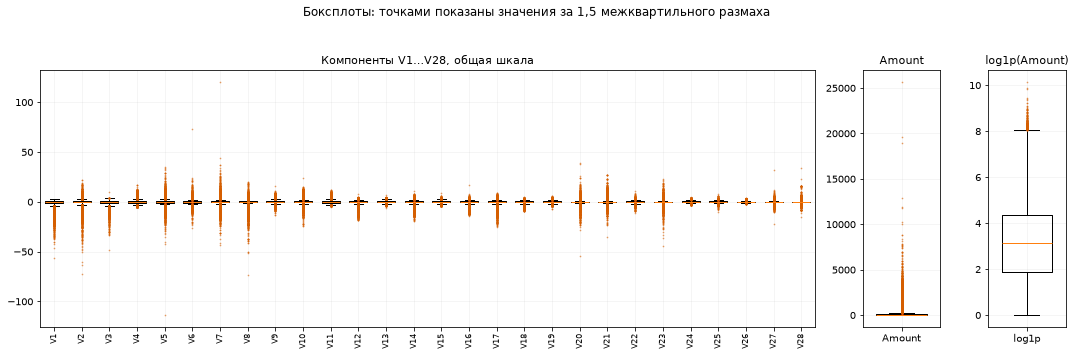

In [17]:
FLIER = {"marker": ".", "markersize": 1.5,
         "markerfacecolor": COLOR_REF, "markeredgecolor": COLOR_REF, "alpha": 0.5}

# Компоненты центрированы и сопоставимы по масштабу, поэтому кладём все 28
# на одну ось — так коробки сравнимы между собой. Amount живёт в своей шкале.
fig, axes = plt.subplots(1, 3, figsize=(15, 5), gridspec_kw={"width_ratios": [10, 1, 1]})

axes[0].boxplot([df[c] for c in V], tick_labels=V, widths=0.65, flierprops=FLIER)
axes[0].tick_params(axis="x", labelsize=8, rotation=90)
axes[0].set_title("Компоненты V1…V28, общая шкала", fontsize=11)

axes[1].boxplot(df["Amount"], tick_labels=["Amount"], widths=0.65, flierprops=FLIER)
axes[1].set_title("Amount", fontsize=11)

axes[2].boxplot(log_amount, tick_labels=["log1p"], widths=0.65, flierprops=FLIER)
axes[2].set_title("log1p(Amount)", fontsize=11)

for ax in axes:
    ax.grid(alpha=0.25, linewidth=0.5)
    ax.set_axisbelow(True)

fig.suptitle("Боксплоты: точками показаны значения за 1,5 межквартильного размаха", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

In [18]:
# Во сколько раз полный размах длиннее коробки — числовая мера того же,
# что видно на боксплоте.
q1 = df[V].quantile(0.25)
q3 = df[V].quantile(0.75)
span_ratio = ((df[V].max() - df[V].min()) / (q3 - q1)).sort_values(ascending=False)

print(f"{'компонента':11} {'размах / IQR':>13}")
for c in list(span_ratio.index[:5]):
    print(f"{c:11} {span_ratio[c]:13.0f}")
print(f"{'...':>11}")
for c in list(span_ratio.index[-3:]):
    print(f"{c:11} {span_ratio[c]:13.0f}")
print()
print(f"медиана отношения по 28 компонентам : {span_ratio.median():.0f}")
print(f"у Amount                            : "
      f"{(df['Amount'].max() - df['Amount'].min()) / (df['Amount'].quantile(0.75) - df['Amount'].quantile(0.25)):.0f}")
print(f"у log1p(Amount)                     : "
      f"{(log_amount.max() - log_amount.min()) / (log_amount.quantile(0.75) - log_amount.quantile(0.25)):.0f}")

компонента   размах / IQR
V28                   375
V27                   335
V20                   272
V23                   218
V8                    174
        ...
V26                    11
V13                    10
V24                     9

медиана отношения по 28 компонентам : 31
у Amount                            : 359
у log1p(Amount)                     : 4


Коробки на фоне хвостов почти не видны. Медиана отношения размаха к межквартильному по 28 компонентам — 31, у `V28` оно 375, у `V27` 335, у `V20` 272. Самое скромное значение, 9 у `V24`, всё равно означает, что хвост вчетверо длиннее коробки в каждую сторону. Это та же тяжесть хвостов, что дала эксцесс 933, только в другой записи.

### Найденные несостыковки

Размер: **284 807 строк × 31 колонка** (30 признаков + метка `Class`). Пропусков нет, все колонки числовые.

**1. Аномалий 492 — 0,1727%, соотношение 1 к 578.**
Модель "всегда нормальная транзакция" даёт accuracy 0,998273. Accuracy неприменима. ROC-AUC при 284 315 отрицательных примерах тоже слабо различает методы: доля ложных срабатываний остаётся низкой при любом пороге. Мерить надо precision и recall на редком классе.

**2. Дубликаты есть: 1081 лишняя копия в 773 группах.**
В самой большой группе 18 одинаковых транзакций. Для методов, основанных на плотности, это критично: 18 совпадающих точек создают сгущение там, где на самом деле одно наблюдение.

**3. `Time` — не признак, а порядок строк.**
Секунды от первой транзакции, ровно 48 часов, строки упорядочены по возрастанию. У новой транзакции значение окажется вне этого диапазона вовсе, поэтому в матрицу признаков `Time` не идёт. Суточный цикл в данных есть и устойчив — провал приходится на четвёртый час в оба дня, 2209 транзакций против 17 703 в двадцать первом, — но час суток мы тоже не берём: точка отсчёта неизвестна (`Time` считается от первой транзакции, а не от полуночи), час цикличен и обычным числом не кодируется, а главное — редкое время стало бы подозрительным по построению, хотя ночь всего лишь редка.

**4. У `Amount` тяжёлый хвост, и компоненты его уже содержат.**
Скошенность 16,98, максимум 102 сигмы, 4076 строк за тремя сигмами. Сырой `Amount` восстанавливается по 28 компонентам с R² = 0,918.

**5. `V1`…`V28` действительно главные компоненты.**
Корреляция Пирсона между ними 2,32e-14, средние порядка 1e-15, дисперсии убывают строго монотонно от 3,836 к 0,109. Следствия: компоненты уже центрированы и ортогональны; приводить их к единичной дисперсии не нужно и вредно, потому что разный масштаб здесь несёт информацию о важности компоненты.

**6. Нулевая корреляция между компонентами — только линейная.**
По Спирмену максимум 0,677 у пары `V21`~`V22`. То есть ортогональность, которую даёт PCA, не означает независимости, и методы, полагающиеся на некоррелированность признаков, здесь опираются на более слабое свойство, чем кажется. Отдельно: `Amount` и `Time` в PCA не входили и с компонентами связаны линейно — `V2`~`Amount` = −0,531, `V3`~`Time` = 0,420.

**7. Масштабы `Time` и `Amount` выбиваются на четыре порядка.**
std 47 488 и 250 против 0,33…1,96 у компонент. Отношение 143 867, в квадратах 2,07e+10. Без обработки эти две колонки определят любое расстояние целиком.

**8. Компоненты не гауссовы.**
У 17 компонент из 28 скошенность по модулю больше единицы, у 19 эксцесс больше трёх, у `V28` он равен 933. За тремя сигмами лежит от 0,23% до 1,68% точек при гауссовой норме 0,27%. Медиана отношения полного размаха к межквартильному — 31.

Что делаем дальше:

- удаляем 1081 лишнюю копию;
- `Time` выбрасываем целиком;
- `Amount` в матрицу не берём вовсе — он дублирует компоненты, а пригодится как цена ошибки;
- компоненты оставляем как есть — они уже центрированы, а разный масштаб у них осмысленный;
- метрики считаем на редком классе, accuracy и ROC-AUC не используем;
- метку держим отдельно от матрицы признаков — она понадобится только чтобы проверить результат.

#### Рабочая гипотеза (сформулирована до экспериментов)

Аномалия здесь — не то же самое, что далёкая точка. Хвосты у компонент тяжёлые: за тремя сигмами лежит до 1,68% всех транзакций, то есть тысячи строк, тогда как аномалий во всём датасете 492. Даже если бы каждая аномалия была далёкой точкой, далёких точек всё равно на порядок больше.

Отсюда три предсказания:

1. Precision будет низкой у любого метода, который меряет удалённость от центра: первые места займёт хвост нормальных данных.
2. Методы, опирающиеся на нормальность распределения, проиграют тем, которые её не предполагают, — предположение здесь нарушено у 19 компонент из 28.

## Предобработка

### Шаг 1. Удаление копий

Убираем строки, у которых совпадают все 30 признаков, оставляя из каждой группы по одной.

In [19]:
# Работаем с копией: df дальше нужен как исходник для сравнений.
data = df.drop_duplicates(subset=FEATURES).reset_index(drop=True)

print(f"было строк    : {len(df):7d}")
print(f"стало         : {len(data):7d}")
print(f"удалено копий : {len(df) - len(data):7d}")
print(f"повторов не осталось : {not data.duplicated(subset=FEATURES).any()}")

было строк    :  284807
стало         :  283726
удалено копий :    1081
повторов не осталось : True


Осталось 283 726 строк из 284 807. Повторов больше нет.

### Шаг 2. Метка отдельно и оценка загрязнённости

Метка уходит из таблицы: методы её не видят. Перед этим берём из неё единственное, что разрешено знать — долю аномалий.

In [20]:
y = (data.pop("Class") == 1).astype(int)

# Экспертная оценка загрязнённости: считаем на очищенных данных,
# потому что именно они пойдут в методы.
CONTAMINATION = y.mean()

print(f"аномалий после дедупликации : {y.sum():7d}")
print(f"доля загрязнения            : {CONTAMINATION:10.4%}")
print(f"она же до дедупликации      : {df['Class'].mean():10.4%}")
print(f"колонок осталось в data     : {data.shape[1]:7d}")

аномалий после дедупликации :     473
доля загрязнения            :    0.1667%
она же до дедупликации      :    0.1727%
колонок осталось в data     :      30


Аномалий 473, доля загрязнения 0,1667%. До дедупликации было 0,1727% — вместе с 1081 копией ушли и 19 аномалий. Разница в четвёртом знаке, но `contamination` передаём методам буквально этим числом, поэтому берём его от той таблицы, на которой будем учиться.

В `data` осталось 30 колонок.

### Шаг 3. `Time` выбрасываем

Это секунды от первой транзакции, диапазон 0…172 792. У новой транзакции значение окажется вне этого диапазона вовсе, так что признаком величина быть не может.

In [21]:
data = data.drop(columns="Time")

print(f"колонок осталось : {data.shape[1]:4d}")
print(f"Time в таблице   : {'Time' in data.columns}")

колонок осталось :   29
Time в таблице   : False


29 колонок: 28 компонент и `Amount`.

### Шаг 4. `Amount` в признаки не идёт

Сумма транзакции — единственная величина, оставшаяся не преобразованной, кроме `Time`. Соблазн взять её в матрицу есть, но в EDA обнаружилось, что компоненты восстанавливают сырой `Amount` с R² = 0,918. Своей информации в нём почти нет.

Низкий R² у `log1p(Amount)` — 0,392 — этого не отменяет. Логарифм однозначно определяется суммой: если компоненты знают сумму, они знают и её логарифм, просто зависимость перестала быть линейной, а R² линейной регрессии меряет только линейную часть. Брать логарифм в матрицу означало бы добавить туда 28 компонент во второй раз, в другой записи.

В описании датасета `Amount` предложен для cost-sensitive постановки — как цена ошибки, а не как признак. Пропустить мошенничество на две тысячи евро дороже, чем на пять, и вот для этого сумма пригодится. Оставляем её отдельно от матрицы, как метку.

In [22]:
raw_amount = data.pop("Amount")

print(f"колонок в матрице : {data.shape[1]}")
print(f"это ровно компоненты : {list(data.columns) == V}")
print()
print(f"суммы сохранены отдельно : {len(raw_amount)} значений,"
      f" медиана {raw_amount.median():.2f} евро")

колонок в матрице : 28
это ровно компоненты : True

суммы сохранены отдельно : 283726 значений, медиана 22.00 евро


В матрице остались 28 компонент и ничего кроме них. Сумма лежит рядом и понадобится на этапе проверки.

### Шаг 5. Матрица признаков

Собираем итоговую матрицу и проверяем, что в ней нет ничего лишнего.

In [23]:
X = data

assert X.shape == (len(y), 28), X.shape
assert not X.isna().any().any(), "появились пропуски"
assert (X.dtypes == "float64").all(), "не все колонки вещественные"
assert "Class" not in X.columns and "Time" not in X.columns
assert list(X.columns) == V, X.columns.tolist()

print(f"матрица признаков : {X.shape[0]} x {X.shape[1]}")
print(f"метка отдельно    : {len(y)} значений, из них аномалий {int(y.sum())}")
X.head()

матрица признаков : 283726 x 28
метка отдельно    : 283726 значений, из них аномалий 473


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153


In [24]:
# Квадрат евклидова расстояния складывает квадраты разностей, поэтому вклад
# признака в расстояние пропорционален его дисперсии.
share = X.var() / X.var().sum()
top = share.sort_values(ascending=False)

print(f"{'признак':10} {'доля расстояния':>16}")
for c in list(top.index[:4]) + list(top.index[-2:]):
    print(f"{c:10} {share[c]:16.2%}")
print()
print(f"максимум {share.max():.2%} ({share.idxmax()}), минимум {share.min():.2%} ({share.idxmin()})")
print(f"отношение max/min : {share.max() / share.min():.1f}")
print()

# Для сравнения — что было бы, оставь мы Time и Amount как есть.
raw = df[V + ["Amount", "Time"]].var()
raw_share = raw / raw.sum()
print("без обработки:")
print(f"    Time                     : {raw_share['Time']:12.6%}")
print(f"    Amount                   : {raw_share['Amount']:12.6%}")
print(f"    все 28 компонент вместе  : {raw_share[V].sum():12.6%}")

признак     доля расстояния
V1                   12.45%
V2                    8.90%
V3                    7.47%
V4                    6.56%
V27                   0.51%
V28                   0.35%

максимум 12.45% (V1), минимум 0.35% (V28)
отношение max/min : 35.3

без обработки:
    Time                     :   99.997225%
    Amount                   :    0.002774%
    все 28 компонент вместе  :    0.000001%


Матрица 283 726 × 29, пропусков нет, всё вещественное.

Ни один признак не перекрывает остальные: наибольшая доля расстояния у `V1` — 12,45%, наименьшая у `V28` — 0,35%, отношение 35. Неравенство осталось, но оно осмысленное: `V1` и должен весить больше, он объясняет больше дисперсии исходных данных.

### Чего сознательно не делаем и почему

**Не масштабируем компоненты.** У PCA дисперсия компоненты — это её важность: 3,795 у `V1` против 0,108 у `V28` говорит о структуре данных, а не о разных единицах измерения. Выровняв их, мы объявили бы `V28` равной `V1` и стёрли бы то, ради чего PCA и делают.

**Не отбираем признаки.** Пар с высокой корреляцией по Пирсону нет ни одной, отбрасывать по взаимной связи нечего. Отбирать по связи с меткой нельзя — её мы не смотрим.

**Не выносим `Amount == 0` отдельным флагом.** Таких строк 1825, и факт нулевой суммы мог бы что-то значить. Но раз сама сумма в матрицу не идёт, то и производный от неё флаг брать непоследовательно.

**Не разбиваем на train и test.** Скейлер обучен на всех данных. Для методов без учителя, которые размечают ту же выборку, на которой построены, это не утечка. Если позже понадобится честная проверка на отложенной части, скейлер придётся переучивать внутри пайплайна.

**Не удаляем выбросы.** В обычной предобработке это стандартный шаг, здесь он бессмыслен: выбросы — то, что мы ищем.

## Методы

Строим методы, разобранные на занятии. Параметры у всех задаём одинаково — через экспертную оценку загрязнённости `CONTAMINATION`, чтобы каждый метод помечал примерно одну и ту же долю строк.

In [25]:
# Матрица одна и та же для всех методов. float32 вдвое экономнее по памяти,
# а точности здесь хватает с запасом.
X_np = X.to_numpy(dtype="float32")

def anomalies_report(mask, name=""):
    "Печатает, сколько строк помечено и какая это доля."
    mask = np.asarray(mask).astype(bool)
    print(f"{name:18} помечено {mask.sum():6d}   {mask.mean():8.4%}")

print(f"матрица       : {X_np.shape[0]} x {X_np.shape[1]}")
print(f"CONTAMINATION : {CONTAMINATION:.6f}")
print(f"это примерно  : {round(CONTAMINATION * len(X_np))} строк")

flags = {}    # маски: кого метод пометил
scores = {}   # непрерывные оценки аномальности, понадобятся для консенсуса

матрица       : 283726 x 28
CONTAMINATION : 0.001667
это примерно  : 473 строк


### Шаг 1. Три сигмы и межквартильный размах

Оба правила работают по одному признаку за раз: точка аномальна, если выходит за границы хотя бы по одной колонке. Классические пороги — 3 сигмы и 1,5 межквартильных размаха.

In [26]:
def std_deviation(matrix):
    "На сколько сигм точка отходит от среднего в худшей своей колонке."
    return np.abs((matrix - matrix.mean(0)) / matrix.std(0)).max(1)

def iqr_deviation(matrix):
    "Во сколько межквартильных размахов точка выходит за квартиль."
    q1 = np.percentile(matrix, 25, axis=0)
    q3 = np.percentile(matrix, 75, axis=0)
    span = q3 - q1
    return np.maximum((q1 - matrix) / span, (matrix - q3) / span).max(1)

sigma = std_deviation(X_np)
iqr = iqr_deviation(X_np)
scores["3 сигмы"], scores["IQR"] = sigma, iqr

# Коэффициенты 3 и 1,5 не перебираем: они и есть сами правила.
print(f"{'правило':18} {'помечено':>9} {'доля':>9}")
print(f"{'3 сигмы':18} {int((sigma > 3).sum()):9d} {(sigma > 3).mean():9.2%}")
print(f"{'1.5 x IQR':18} {int((iqr > 1.5).sum()):9d} {(iqr > 1.5).mean():9.2%}")
print(f"{'экспертная оценка':18} {round(CONTAMINATION * len(X_np)):9d} {CONTAMINATION:9.2%}")
print()

# Не настройка, а измерение промаха: какой порог понадобился бы ради этой доли.
print("до какого порога пришлось бы дойти:")
print(f"    сигм            : {np.quantile(sigma, 1 - CONTAMINATION):5.2f}   вместо 3")
print(f"    межкв. размахов : {np.quantile(iqr, 1 - CONTAMINATION):5.2f}   вместо 1.5")

правило             помечено      доля
3 сигмы                36709    12.94%
1.5 x IQR             128084    45.14%
экспертная оценка        473     0.17%

до какого порога пришлось бы дойти:
    сигм            : 17.85   вместо 3
    межкв. размахов : 35.08   вместо 1.5


Оба правила здесь не работают. Правило трёх сигм помечает 36 709 строк — 12,94% датасета, правило 1,5 межквартильных размаха — 128 084 строки, 45,14%. Объявить аномалией почти половину данных значит не сказать ничего.

Причина в форме распределений: константы 3 и 1,5 выведены для гауссова случая, а у нас 19 компонент из 28 с эксцессом больше трёх.

Подбирать коэффициент под экспертную оценку не станем: 3 и 1,5 — это и есть сами правила, а не их настройка.Размер промаха эти числа показывают наглядно: чтобы выйти на 0,1667%, порог надо поднять в шесть раз у сигм и в двадцать три у межквартильного размаха.

Дальше оба правила участвуют только своими непрерывными оценками — по ним можно ранжировать строки, даже если фиксированный порог никуда не годится.

### Шаг 2. Расстояние до центроида

Считаем центр облака и расстояние до него, аномалией объявляем самые далёкие точки. Порог задаём перцентилем, и перцентиль берём из экспертной оценки. Две метрики: евклидова и манхэттенская.

In [27]:
from sklearn.base import BaseEstimator
from scipy.spatial.distance import cdist

class DistanceOutliers(BaseEstimator):
    "Аномалия — точка дальше заданного перцентиля расстояний до центроида."

    def __init__(self, metric="euclidean", percentile=95):
        self.metric = metric
        self.percentile = percentile

    def fit(self, matrix):
        self.centroid_ = matrix.mean(0)[np.newaxis, :]
        distances = cdist(self.centroid_, matrix, metric=self.metric).ravel()
        self.threshold_ = np.percentile(distances, self.percentile)
        return self

    def predict(self, matrix):
        distances = cdist(self.centroid_, matrix, metric=self.metric).ravel()
        return distances > self.threshold_

# Перцентиль из экспертной оценки: отсекаем верхние 0,1667% расстояний.
PERCENTILE = 100 * (1 - CONTAMINATION)
print(f"перцентиль по умолчанию   : 95")
print(f"перцентиль из оценки      : {PERCENTILE:.4f}")
print()

for metric in ["euclidean", "cityblock"]:
    centroid = X_np.mean(0)[np.newaxis, :]
    scores[metric] = cdist(centroid, X_np, metric=metric).ravel()

    default = DistanceOutliers(metric=metric, percentile=95).fit(X_np)
    anomalies_report(default.predict(X_np), f"{metric}, p95")

    model = DistanceOutliers(metric=metric, percentile=PERCENTILE).fit(X_np)
    flags[metric] = model.predict(X_np)
    print(f"{'':18} порог расстояния {model.threshold_:8.2f}")
    anomalies_report(flags[metric], f"{metric}, оценка")
    print()

перцентиль по умолчанию   : 95
перцентиль из оценки      : 99.8333

euclidean, p95     помечено  14187    5.0002%
                   порог расстояния    30.50
euclidean, оценка  помечено    473    0.1667%

cityblock, p95     помечено  14187    5.0002%
                   порог расстояния   101.82
cityblock, оценка  помечено    473    0.1667%



Перцентиль по умолчанию 95 помечает 14 187 строк — 5% данных, в тридцать раз больше экспертной оценки. Само число 95 никакого отношения к данным не имеет, это просто круглая величина.

С перцентилем из оценки оба метода помечают ровно 473 строки — так и задумано, перцентиль это гарантирует. Пороги расстояния разные, потому что метрики разные: 30,50 у евклидовой против 101,82 у манхэттенской, и это ожидаемо — манхэттенская складывает модули по 28 осям, а не берёт корень из суммы квадратов.

### Шаг 3. DBSCAN

Идея в том, что аномалии не попадут ни в один плотный кластер и останутся шумом.

У расстояний перцентиль задавал только рабочую точку — сколько строк объявить аномальными — и брать его из экспертной оценки было честно. У DBSCAN оба параметра, `eps` и `min_samples`, определяют само разбиение: от них зависит, сколько будет кластеров и какой формы. Подставлять сюда числа, посчитанные по метке, значит подсматривать ответ там, где данные могут ответить сами. Поэтому оба выбираем без метки, а с экспертной оценкой сравниваем то, что получилось.

На всех 283 726 строках метод не запускается: при `eps` больше трёх списки соседей перестают помещаться в память, 36 ГБ не хватает. Обучаем на подвыборке в 10 000 строк, а размечать будем всё.

In [28]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

SUBSAMPLE = 10_000
rng = np.random.default_rng(42)
X_sub = X_np[rng.choice(len(X_np), SUBSAMPLE, replace=False)]


def elbow_eps(matrix, min_samples):
    "Локоть на графике расстояний до min_samples-го соседа."
    k_dist = np.sort(NearestNeighbors(n_neighbors=min_samples)
                     .fit(matrix).kneighbors(matrix)[0][:, -1])
    # Кривая выпуклая и лежит ниже хорды, поэтому максимизируем straight - curve.
    straight = np.linspace(0, 1, len(k_dist))
    curve = (k_dist - k_dist.min()) / (k_dist.max() - k_dist.min())
    return k_dist, float(k_dist[int(np.argmax(straight - curve))])


def describe(labels):
    "Число кластеров, их размеры и маска шума."
    sizes = sorted((int((labels == c).sum()) for c in set(labels) - {-1}), reverse=True)
    return sizes, labels == -1

In [29]:
# min_samples тоже параметр разбиения, поэтому перебираем и его.
# График k-расстояний строится по расстоянию до min_samples-го соседа,
# так что для каждого значения локоть свой.
print(f"{'min_samples':>12} {'локоть eps':>11} {'кластеров':>10} {'размеры':>20} {'шума':>7} {'доля':>8}")
for ms in [3, 5, 10, 20, 30, 58]:
    _, eps = elbow_eps(X_sub, ms)
    sizes, is_noise = describe(DBSCAN(eps=eps, min_samples=ms, n_jobs=-1).fit(X_sub).labels_)
    print(f"{ms:12d} {eps:11.2f} {len(sizes):10d} {str(sizes[:3]):>20}"
          f" {int(is_noise.sum()):7d} {is_noise.mean():8.2%}")
print()
print(f"ln(n) при n = {SUBSAMPLE} : {np.log(SUBSAMPLE):.1f}")

 min_samples  локоть eps  кластеров              размеры    шума     доля
           3        4.12         10         [9506, 5, 4]     464    4.64%
           5        4.71          2            [9653, 5]     342    3.42%
          10        5.19          1               [9715]     285    2.85%
          20        5.53          1               [9738]     262    2.62%
          30        5.80          1               [9767]     233    2.33%
          58        6.23          1               [9784]     216    2.16%

ln(n) при n = 10000 : 9.2


От `min_samples` ответ почти не зависит: при значениях от 10 до 58 DBSCAN находит **один** кластер, а шума получается от 2,16% до 2,85%. 

При малых `min_samples` кластеров формально больше: десять при трёх и два при пяти. Но размеры выдают их природу — 9506, 5 и 4 точки: одно облако и несколько горсток, а не структура.

Берём `min_samples = 10`, порядка `ln(n)` = 9,2 для наших десяти тысяч точек. Рекомендация `2 × размерность` дала бы 58 — для 29 измерений это слишком строго, при таком требовании кластер не соберётся почти нигде, и метод превращается в детектор одиночек ещё до того, как мы что-то настроили.

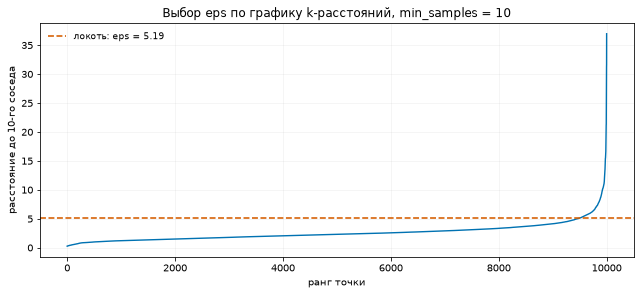

   eps  кластеров          размеры    шума     доля   силуэт
  3.00          4      [7375, 438]    1738   17.38%    0.165
  4.00          1           [9361]     639    6.39%        —
  5.00          1           [9684]     316    3.16%        —
  5.19          1           [9715]     285    2.85%        —
  6.00          1           [9815]     185    1.85%        —
  7.00          1           [9882]     118    1.18%        —
  8.00          1           [9921]      79    0.79%        —
 10.00          1           [9959]      41    0.41%        —


In [30]:
MIN_SAMPLES = 10
k_dist, EPS_ELBOW = elbow_eps(X_sub, MIN_SAMPLES)

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(k_dist, color=COLOR_MAIN, linewidth=1.4)
ax.axhline(EPS_ELBOW, color=COLOR_REF, linestyle="--", linewidth=1.6,
           label=f"локоть: eps = {EPS_ELBOW:.2f}")
ax.set_xlabel("ранг точки")
ax.set_ylabel(f"расстояние до {MIN_SAMPLES}-го соседа")
ax.set_title(f"Выбор eps по графику k-расстояний, min_samples = {MIN_SAMPLES}", fontsize=12)
ax.grid(alpha=0.25, linewidth=0.5)
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

# Второй способ выбрать eps без метки — силуэт.
print(f"{'eps':>6} {'кластеров':>10} {'размеры':>16} {'шума':>7} {'доля':>8} {'силуэт':>8}")
for eps in sorted([3.0, 4.0, 5.0, EPS_ELBOW, 6.0, 7.0, 8.0, 10.0]):
    labels = DBSCAN(eps=eps, min_samples=MIN_SAMPLES, n_jobs=-1).fit(X_sub).labels_
    sizes, is_noise = describe(labels)
    if len(sizes) >= 2:
        sil = f"{silhouette_score(X_sub[~is_noise], labels[~is_noise], sample_size=5000, random_state=0):8.3f}"
    else:
        sil = f"{'—':>8}"   # силуэту нужно минимум два кластера
    print(f"{eps:6.2f} {len(sizes):10d} {str(sizes[:2]):>16} {int(is_noise.sum()):7d}"
          f" {is_noise.mean():8.2%} {sil}")

Силуэт не помогает. Второй кластер возникает только при `eps = 3`, где силуэт равен 0,165 — очень плохо — а шумом объявляется 17,38% данных. На всех остальных `eps` кластер один и силуэт не определён.

Остаётся локоть: `eps = 5.19`. Кривая k-расстояний перегиба почти не имеет, полого растёт до девяти тысяч точек и уходит вертикально на последней сотне, так что и это выбор с большой погрешностью — глазом можно назвать и 4, и 7.

In [31]:
db = DBSCAN(eps=EPS_ELBOW, min_samples=MIN_SAMPLES, n_jobs=-1).fit(X_sub)
sizes, sub_noise = describe(db.labels_)

print(f"min_samples : {MIN_SAMPLES}")
print(f"eps         : {EPS_ELBOW:.2f}")
print(f"кластеров   : {len(sizes)}  размеры {sizes}")
anomalies_report(sub_noise, "на подвыборке")

min_samples : 10
eps         : 5.19
кластеров   : 1  размеры [9715]
на подвыборке      помечено    285    2.8500%


In [32]:
# У DBSCAN нет predict, но правило разметки новой точки определено самим методом:
# точка шумовая, если она дальше eps от всех ядровых точек. Это и переносим
# на полные данные, а расстояние до ближайшей ядровой берём как оценку аномальности.
core = X_sub[db.core_sample_indices_]
distance_to_core = NearestNeighbors(n_neighbors=1).fit(core).kneighbors(X_np)[0].ravel()

scores["DBSCAN"] = distance_to_core
flags["DBSCAN"] = distance_to_core > EPS_ELBOW

print(f"ядровых точек в подвыборке : {len(core)}")
print(f"медиана расстояния до ядра : {np.median(distance_to_core):.2f}")
anomalies_report(flags["DBSCAN"], "на всех данных")
print(f"экспертная оценка          : {CONTAMINATION:8.4%}")
print(f"расхождение                : в {flags['DBSCAN'].mean() / CONTAMINATION:.0f} раз")

ядровых точек в подвыборке : 9527
медиана расстояния до ядра : 1.39
на всех данных     помечено   8050    2.8372%
экспертная оценка          :  0.1667%
расхождение                : в 17 раз


Разметка перенеслась согласованно: 2,85% шума на подвыборке против 2,84% на всех данных — подвыборка оказалась представительной.

Итог метода: 8050 подозрительных строк, 2,84% против экспертных 0,17%, расхождение в семнадцать раз. Предоставленный сам себе, DBSCAN считает подозрительной каждую тридцать пятую транзакцию.

И главное, что он сообщает про данные: кластеров здесь нет. Ни при каком сочетании `eps` и `min_samples` не возникает двух сопоставимых по размеру групп — только одно облако и отвалившиеся от него точки. Это согласуется с нулевыми корреляциями между компонентами и с одномодальными гистограммами.

### Шаг 4. One-Class SVM

Строит вокруг плотной части данных границу произвольной формы: не сферу, как расстояние до центроида, а очертания, повторяющие облако. Достигается это ядром — вместо координат метод работает с попарными «похожестями» `K(a, b) = exp(-gamma * d(a,b)^2)`, которые близки к единице у соседних точек и к нулю у далёких.

Параметр `nu` — доля точек, которым разрешено оказаться снаружи. Своего значения данные для него не подсказывают. Это ровно тот параметр, ради которого экспертная оценка и нужна — как `contamination` у леса и перцентиль у расстояний.

In [33]:
from sklearn.svm import OneClassSVM
from scipy.stats import spearmanr

# На всех данных обучение идёт минутами, поэтому чужие nu смотрим
# на той же подвыборке в 10 000 строк.
svm_scores = {}
for nu in [0.5, 0.05, CONTAMINATION]:
    model = OneClassSVM(nu=nu, gamma="scale").fit(X_sub)
    svm_scores[nu] = -model.decision_function(X_sub)
    outside = model.predict(X_sub) == -1
    note = {0.5: "по умолчанию в sklearn", 0.05: "значение с занятия"}.get(nu, "экспертная оценка")
    print(f"nu = {nu:<9.6f} снаружи {outside.mean():7.2%}   {note}")
print()

# decision_function даёт каждой строке число. Отсортировав по нему, получаем
# очередь подозреваемых: место 1 — самая аномальная строка. Если бы nu задавал
# только порог, очередь при разных nu была бы одна и та же. Проверяем.
place = {nu: pd.Series(score).rank(ascending=False)
         for nu, score in svm_scores.items()}
base = place[CONTAMINATION]

print("насколько очередь совпадает с очередью при экспертной оценке:")
print(f"{'nu':>10} {'Спирмен':>9} {'сдвинулись > 1000 мест':>24} {'макс. сдвиг':>13}")
for nu in [0.05, 0.5]:
    shift = (place[nu] - base).abs()
    print(f"{nu:10} {spearmanr(place[nu], base).statistic:9.4f}"
          f" {(shift > 1000).mean():24.1%} {int(shift.max()):13d}")
print(f"\nвсего строк в подвыборке: {len(base)}")

nu = 0.500000  снаружи  50.01%   по умолчанию в sklearn
nu = 0.050000  снаружи   5.07%   значение с занятия
nu = 0.001667  снаружи   1.93%   экспертная оценка

насколько очередь совпадает с очередью при экспертной оценке:
        nu   Спирмен   сдвинулись > 1000 мест   макс. сдвиг
      0.05    0.9928                     1.9%          2987
       0.5    0.8074                    53.7%          7353

всего строк в подвыборке: 10000


In [34]:
svm = OneClassSVM(nu=CONTAMINATION, kernel="rbf", gamma="scale")
flags["OneClassSVM"] = svm.fit_predict(X_np) == -1
scores["OneClassSVM"] = -svm.decision_function(X_np)

print(f"опорных векторов : {svm.support_vectors_.shape[0]}")
anomalies_report(flags["OneClassSVM"], "nu = оценка")
print(f"ожидалось около  : {round(CONTAMINATION * len(X_np))}")
print()

# Ядро гаснет как exp(-gamma * d^2): смотрим, с какого расстояния
# далёкие точки становятся для него неразличимы.
gamma = 1 / (X_np.shape[1] * X_np.var())
print(f"gamma = 1 / (29 * дисперсия) = {gamma:.4f}")
print(f"{'расстояние':>11} {'K':>11}")
for d in [2, 6, 10, 20, 40]:
    print(f"{d:11d} {np.exp(-gamma * d ** 2):11.2e}")
print()

top = np.sort(scores["OneClassSVM"])[::-1]
print(f"вся решающая функция : от {scores['OneClassSVM'].min():.6f} до {top[0]:.6f}")
print(f"её верхние 473       : от {top[472]:.6f} до {top[0]:.6f}")

опорных векторов : 2339
nu = оценка        помечено   1161    0.4092%
ожидалось около  : 473

gamma = 1 / (29 * дисперсия) = 0.0328
 расстояние           K
          2    8.77e-01
          6    3.07e-01
         10    3.76e-02
         20    1.99e-06
         40    1.57e-23

вся решающая функция : от -1.063536 до 0.000480
её верхние 473       : от 0.000198 до 0.000480


Значение по умолчанию `nu = 0.5` помечает ровно половину данных — им пользоваться нельзя вовсе. Значение с занятия, 0,05, даёт 5,07% и тоже взято круглым числом, а не из данных. Экспертная оценка здесь единственный осмысленный источник.

**`nu` задаёт не только порог.** Если бы он лишь выбирал, где отрезать очередь подозреваемых, то сама очередь при любом `nu` была бы одна и та же. Проверка показывает другое: при `nu = 0.5` совпадение с очередью по экспертной оценке всего 0,81 по Спирмену, и больше половины строк переезжают дальше чем на тысячу мест. При близком `nu = 0.05` порядок почти сохраняется — 0,99.

Значит `nu` перестраивает и саму границу, а не только точку отсечения. Этим он отличается от `contamination` у `IsolationForest`: там деревья строятся одинаково при любом значении, меняется только порог у готовых оценок. Подставляя сюда экспертную оценку, мы частично формируем и модель — случай менее чистый, чем у леса.

**В заданную долю метод не попал:** 1161 строка, 0,4092% вместо 0,1667%. `nu` ограничивает долю точек за отступом сверху и долю опорных векторов снизу, но равенства не обещает, а `predict` возвращает −1 и тем, кто до отступа чуть-чуть не дотянул. Нужны ровно 473 строки — надо брать `decision_function` и резать по квантилю, как делали с расстояниями.

Ядро гаснет очень быстро: при `gamma = 0.0328` значение `K` падает с 0,88 на расстоянии 2 до 2e-06 на расстоянии 20. Дальше двадцати единиц все точки для ядра одинаковы, и различать "далеко" и "очень далеко" метод уже не может. Видно это по решающей функции: она пробегает диапазон от −1,06 до +0,0005, а все верхние 473 строки умещаются в отрезок шириной три десятитысячных — 0,03% шкалы. Порядок внутри этого слоя держится на различиях порядка 1e-4 и потому неустойчив.

### Шаг 5. Isolation Forest

Строит случайные деревья и смотрит, за сколько разбиений точка отделяется от остальных. Чем быстрее отделяется, тем аномальнее. Параметр `contamination` принимает экспертную оценку прямо.

In [35]:
from sklearn.ensemble import IsolationForest

# По умолчанию contamination="auto": порог берётся из теории, а не из данных.
default_forest = IsolationForest(contamination="auto", n_estimators=100,
                                 random_state=42, n_jobs=-1)
anomalies_report(default_forest.fit_predict(X_np) == -1, "auto")

forest = IsolationForest(contamination=CONTAMINATION, n_estimators=100,
                         random_state=42, n_jobs=-1)
flags["IsolationForest"] = forest.fit_predict(X_np) == -1
scores["IsolationForest"] = -forest.score_samples(X_np)

anomalies_report(flags["IsolationForest"], "оценка")
print(f"порог решающей функции : {forest.offset_:.4f}")

auto               помечено   9551    3.3663%
оценка             помечено    473    0.1667%
порог решающей функции : -0.6609


С `contamination="auto"` помечено 9551 строка, 3,37%: порог берётся из теории изолирующих деревьев, а не из данных, и промахивается в двадцать раз.

С оценкой помечено ровно 473 строки — `IsolationForest` считает оценку для всех точек и сам режет её по квантилю, поэтому в заданную долю попадает точно.

### Что в итоге

Наборы у методов разного размера: три сигмы помечают 12,94%, DBSCAN — 2,86%, `IsolationForest` — 3,3663%. Сравнивать их напрямую бессмысленно, поэтому у каждого метода берём его верхние 473 строки по его собственной оценке аномальности. Размер у всех становится одинаковым, и видно, показывают ли они на одни и те же строки.

In [36]:
# Наборы разного размера сравнивать нельзя: три сигмы помечают 12,94%,
# а IsolationForest 0,1667%. Поэтому у каждого метода берём его собственные
# TARGET верхних строк по его же оценке. Методы это не настраивает —
# просто приводит их ответы к одному размеру.
ranks = pd.DataFrame(scores).rank(ascending=False, method="average")
TARGET = round(CONTAMINATION * len(X_np))
top = ranks <= TARGET
votes = top.sum(axis=1)

print(f"у каждого метода берём его верхние {TARGET} строк")
print()
print(f"помечено хотя бы одним методом : {int((votes > 0).sum()):6d}")
print(f"помечено всеми семью           : {int((votes == len(top.columns)).sum()):6d}")
print()
print("на скольких методах сошлись:")
for k, count in votes.value_counts().sort_index().items():
    if k:
        print(f"    ровно на {k} : {count:6d}")

у каждого метода берём его верхние 473 строк

помечено хотя бы одним методом :   1171
помечено всеми семью           :     31

на скольких методах сошлись:
    ровно на 1 :    533
    ровно на 2 :    134
    ровно на 3 :     87
    ровно на 4 :     74
    ровно на 5 :    136
    ровно на 6 :    176
    ровно на 7 :     31


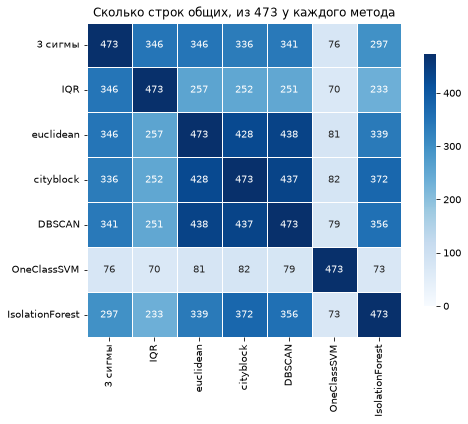

In [37]:
# Наборы одинакового размера, поэтому достаточно посчитать общие строки.
names = list(top.columns)
shared = pd.DataFrame(index=names, columns=names, dtype=int)
for a in names:
    for b in names:
        shared.loc[a, b] = int((top[a] & top[b]).sum())

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(shared.astype(int), annot=True, fmt="d", cmap="Blues",
            vmin=0, vmax=TARGET, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title(f"Сколько строк общих, из {TARGET} у каждого метода", fontsize=12)
plt.tight_layout()
plt.show()

Методы показывают на разные строки. В верхние 473 хотя бы у одного метода попала 1171 строка, а у всех семи сразу — только 31. Из 1171 подозреваемого лишь каждый тридцать восьмой выглядит аномальным со всех точек зрения, а 533 строки держатся на одном-единственном методе.

Самое неожиданное в матрице — DBSCAN. С евклидовым расстоянием у него 438 общих строк из 473, с манхэттенским 437, то есть он ближе к ним, чем они друг к другу (428). Метод, который должен был искать плотность, на этих данных выродился в измерение удалённости — ровно то, что было видно по единственному кластеру.

`IsolationForest` тяготеет к той же группе (339…372), но не сливается с ней. Правило трёх сигм ближе к расстояниям (336…346), чем межквартильное правило, у которого с расстояниями лишь 252…257.

Дальше всех от всех `OneClassSVM` — 70…82 общих строки с каждым, то есть пересечение почти пустое. Списать это на размер набора нельзя: здесь у всех ровно по 473 строки. Он действительно смотрит в другую сторону — граница вокруг плотной области устроена иначе, чем расстояние до центра.

Отдельно стоит собрать, что каждый метод сказал бы, если бы никакой оценки у нас не было:

| метод | настройка | помечено |
|---|---|---:|
| 3 сигмы | порог 3 — это само правило | 12,94% |
| IQR | множитель 1,5 — это само правило | 45,14% |
| euclidean, cityblock | перцентиль 95 по умолчанию | 5,00% |
| DBSCAN | локоть и `min_samples` из данных | 2,86% |
| One-Class SVM | `nu = 0.05` по умолчанию | 5,03% |
| Isolation Forest | `contamination="auto"` | 3,37% |
| | экспертная оценка | **0,17%** |

Ни одна настройка не подходит даже близко: разброс от 2,86% до 45,14% при цели 0,17%. Показательно, что ближе всех подошёл DBSCAN — единственный, у кого параметры выбирались по самим данным, а не взяты круглым числом. Но и он промахнулся в семнадцать раз. У двух верхних правил это приговор самим правилам, у остальных трёх — свидетельство того, что умолчания там круглые числа, а не свойство данных. Без внешней оценки доли аномалий любой из шести пометил бы на два порядка больше нужного.

Так что оценка здесь не роскошь, а единственное, что удерживает методы от произвола. Но пользоваться ею можно по-разному, и до сих пор мы делали это не лучшим образом.

### Попробуем сделать агрегат

In [38]:
# ranks и TARGET посчитаны в сводке выше.
# Ранги, а не сами оценки: у методов разные шкалы, складывать их напрямую нельзя.
mean_rank = ranks.mean(axis=1)
consensus = (mean_rank.rank(method="first") <= TARGET).values

print(f"методов в агрегате   : {ranks.shape[1]}")
print(f"свободных параметров : 0")
print(f"оценка применена     : один раз, чтобы отрезать топ-{TARGET}")
print()
anomalies_report(consensus, "средний ранг")
print()

# Сколько методов независимо согласны с итоговым набором.
agreement = (ranks.loc[consensus] <= TARGET).sum(axis=1)
print(f"сколько из {ranks.shape[1]} методов сами пометили бы эти строки:")
for k, count in agreement.value_counts().sort_index().items():
    print(f"    {k} метод(ов) : {count:4d}")

методов в агрегате   : 7
свободных параметров : 0
оценка применена     : один раз, чтобы отрезать топ-473

средний ранг       помечено    473    0.1667%

сколько из 7 методов сами пометили бы эти строки:
    0 метод(ов) :    6
    1 метод(ов) :   19
    2 метод(ов) :   34
    3 метод(ов) :   47
    4 метод(ов) :   50
    5 метод(ов) :  114
    6 метод(ов) :  172
    7 метод(ов) :   31


Агрегат устроен просто: каждый метод выстраивает все 283 726 строк в свою очередь по аномальности, места в семи очередях усредняются, сверху отрезается столько строк, сколько назвал эксперт. Подкручивать нечего — ни ширины, ни порога голосования, ни весов у методов.

Внутри полученных 473 строк согласие очень разное. Всеми семью методами сами по себе была бы помечена 31 строка, шестью — 172, а шесть строк не вошли в топ-473 ни у одного метода: они попали в итог исключительно за счёт стабильно высокого места у всех сразу.

Это и есть свойство агрегации по рангам. Она поднимает наверх точки, подозрительные умеренно, но единодушно, и в этом одновременно её сила и её риск. Риск здесь предметный: из семи методов четыре — два расстояния до центроида, DBSCAN и отчасти правило трёх сигм — меряют по сути одну и ту же удалённость, и общих строк у них по 428…438 из 473. Их единодушие не является независимым подтверждением, а вес в среднем ранге они имеют такой же, как непохожий на них `OneClassSVM`.

### Насколько ответ зависит от способа агрегации

Средний ранг — не единственный вариант. Проверяем, что было бы при голосовании, и заодно измеряем цену вопроса.

In [39]:
# ВНИМАНИЕ: ширину подбираем под известное число 473 — это ровно та подгонка,
# от которой мы отказались. Считаем её не как метод, а как измерение разброса.
def widen_until(votes_needed, target):
    "Наименьшее N, при котором столько-то голосов набирает target строк."
    low, high = target, len(ranks)
    while low < high:
        mid = (low + high) // 2
        if int(((ranks <= mid).sum(axis=1) >= votes_needed).sum()) < target:
            low = mid + 1
        else:
            high = mid
    return low

variants = {"средний ранг": consensus}
for votes_needed in [5, 6]:
    top_n = widen_until(votes_needed, TARGET)
    variants[f"{votes_needed} голосов"] = ((ranks <= top_n).sum(axis=1) >= votes_needed).values
    print(f">= {votes_needed} голосов дают {TARGET} строк при топ-{top_n} у каждого"
          f"  ({top_n / len(X_np):.2%} данных)")
print()

names = list(variants)
print(f"{'пара вариантов':38} {'общих строк':>13} {'из':>5}")
for i, a in enumerate(names):
    for b in names[i + 1:]:
        both = int((variants[a] & variants[b]).sum())
        print(f"{a + ' & ' + b:38} {both:13d} {TARGET:5d}")

>= 5 голосов дают 473 строк при топ-665 у каждого  (0.23% данных)
>= 6 голосов дают 473 строк при топ-1025 у каждого  (0.36% данных)

пара вариантов                           общих строк    из
средний ранг & 5 голосов                         410   473
средний ранг & 6 голосов                         399   473
5 голосов & 6 голосов                            387   473


Три способа собрать согласие дают три разных набора по 473 строки: общих у них 387…410, то есть в каждой паре различается около шестой части.

Вывод не в том, какой вариант лучше. Вывод в том, что "взять то, на чём методы сошлись" — не однозначная операция: результат зависит от определения согласия не меньше, чем от самих методов. Поэтому в качестве ответа оставляем средний ранг — единственный вариант, где нечего подкручивать.

Насколько все три набора близки к настоящим аномалиям, здесь по-прежнему не проверяется.

## Проверка по метке

До сих пор `Class` участвовал одним числом — долей загрязнённости. Теперь открываем метку целиком и смотрим, попали ли методы в настоящие аномалии.

Устройство сравнения задано тем, что уже сделано: у каждого метода отобрано 473 строки, и настоящих аномалий тоже 473.

### Шаг 1. Confusion matrix и classification report

Разбираем подробно один метод — DBSCAN.

In [40]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             average_precision_score, roc_auc_score)

y_true = y.values
BEST = "DBSCAN"
y_pred = top[BEST].astype(int).values

print(confusion_matrix(y_true, y_pred))
print()
print(classification_report(y_true, y_pred,
                            target_names=["норма", "аномалия"], digits=4))

[[282904    349]
 [   349    124]]

              precision    recall  f1-score   support

       норма     0.9988    0.9988    0.9988    283253
    аномалия     0.2622    0.2622    0.2622       473

    accuracy                         0.9975    283726
   macro avg     0.6305    0.6305    0.6305    283726
weighted avg     0.9975    0.9975    0.9975    283726



Матрица получилась симметричной: 349 ложных тревог и ровно столько же пропущенных аномалий. Это не совпадение, а следствие того, как мы всё построили: раз предсказано 473 строки и настоящих аномалий 473, то каждая лишняя ложная тревога забирает место у пропущенной аномалии. Поэтому precision, recall и f1 у нас всегда равны между собой — 0,2622.

Из 473 аномалий найдено 124.

Отдельного внимания заслуживает accuracy — 0,9975. Модель «всё нормально», не находящая ни одной аномалии, даёт 0,9983. То есть **по accuracy наш детектор хуже, чем не делать ничего**: он добавил 349 ложных тревог, а исправил 124 ошибки. Ровно то, о чём шла речь в первом шаге EDA, только теперь с числами.

### Шаг 2. Все методы разом

Считаем то же самое для каждого. Добавляем две метрики, не зависящие от выбранного порога: average precision по всей очереди подозреваемых и ROC-AUC.

In [41]:
report = []
for name in list(top.columns) + ["средний ранг"]:
    if name == "средний ранг":
        selected, score = consensus, -mean_rank.values
    else:
        selected, score = top[name].values, scores[name]
    hits = int((selected & (y_true == 1)).sum())
    report.append({
        "метод": name,
        "нашёл": hits,
        "precision": hits / TARGET,
        "AP": average_precision_score(y_true, score),
        "ROC-AUC": roc_auc_score(y_true, score),
    })

report = pd.DataFrame(report).set_index("метод").sort_values("precision", ascending=False)
print(report.to_string(float_format=lambda v: f"{v:.4f}"))
print()
print(f"случайные {TARGET} строк дали бы   : {TARGET * TARGET / len(y_true):.2f} попаданий,"
      f" precision {TARGET / len(y_true):.4%}")
print(f"лучший метод лучше случая в : {report['precision'].max() / (TARGET / len(y_true)):.0f} раз")

                 нашёл  precision     AP  ROC-AUC
метод                                            
IsolationForest    133     0.2812 0.1882   0.9478
DBSCAN             124     0.2622 0.1953   0.9547
cityblock          121     0.2558 0.1753   0.9491
euclidean           99     0.2093 0.1388   0.9478
средний ранг        86     0.1818 0.1013   0.9493
3 сигмы             76     0.1607 0.0970   0.9453
OneClassSVM         43     0.0909 0.0632   0.9157
IQR                 11     0.0233 0.0280   0.9316

случайные 473 строк дали бы   : 0.79 попаданий, precision 0.1667%
лучший метод лучше случая в : 169 раз


Методы работают — но плохо. Лучший, `IsolationForest`, находит 133 аномалии из 473, precision 0,281. Случайный отбор 473 строк дал бы меньше одного попадания, так что выигрыш над случаем стосемидесятикратный. И при этом почти три четверти тревог ложные.

Второй результат у DBSCAN — 124 попадания, хотя на прошлом шаге он не нашёл ни одного осмысленного кластера. Худший — правило межквартильного размаха: 11 попаданий из 473, precision 0,023, всего в четырнадцать раз лучше случая.

Главное же в колонке ROC-AUC: у всех методов от 0,916 до 0,955. По этой метрике все они выглядят отличными классификаторами, тогда как на деле три четверти их тревог ложные. Предупреждение из первого шага EDA подтвердилось буквально: при 283 253 отрицательных примерах доля ложных срабатываний остаётся ничтожной при любом пороге, и ROC-AUC этого не замечает. Average precision, считающая по редкому классу, честнее — 0,028…0,195.

### Шаг 3. Помог ли консенсус

Средний ранг стоит в таблице отдельной строкой, и это самый неудобный результат.

In [42]:
print(f"{'':22} {'precision':>10}")
for name in ["DBSCAN", "IsolationForest", "cityblock", "средний ранг"]:
    print(f"{name:22} {report.loc[name, 'precision']:10.3f}")
print()

# Сколько попаданий в верхних k строках у разных методов.
queue = {name: ranks[name].values for name in ["DBSCAN", "IsolationForest", "cityblock"]}
queue["средний ранг"] = mean_rank.rank(method="first").values

print(f"{'k':>7} " + "".join(f"{name:>17}" for name in queue))
for k in [100, 200, TARGET, 1000, 5000]:
    line = f"{k:7d} "
    for name in queue:
        line += f"{y_true[queue[name] <= k].sum() / k:17.3f}"
    print(line)

                        precision
DBSCAN                      0.262
IsolationForest             0.281
cityblock                   0.256
средний ранг                0.182

      k            DBSCAN  IsolationForest        cityblock     средний ранг
    100             0.280            0.490            0.410            0.100
    200             0.495            0.430            0.485            0.155
    473             0.262            0.281            0.256            0.182
   1000             0.207            0.181            0.173            0.137
   5000             0.078            0.069            0.068            0.066


Агрегация не помогла, а помешала. Средний ранг даёт precision 0,182 против 0,281 у `IsolationForest` и 0,262 у DBSCAN поодиночке, и проигрывает им на всех глубинах: в верхней сотне 0,100 против 0,490 и 0,280.

Причина названа ещё до проверки. Из семи методов четыре — два расстояния до центроида, DBSCAN и правило трёх сигм — меряют по сути одну и ту же удалённость от центра, что было видно по числу общих строк. В среднем ранге они голосуют вчетвером за одно и то же и перевешивают всё остальное, а слабый вклад `IQR` и `OneClassSVM` при этом никуда не девается и тянет вниз.

Урок общий: усреднение помогает, когда ошибки методов независимы. Здесь они не независимы, и "мудрость толпы" превращается в повторённое вчетверо мнение одного.

### Шаг 4. Сколько удаётся поймать, если расширить поиск

Порог в 473 строки задан экспертной оценкой, но на практике проверять можно больше — вопрос в бюджете на ручной разбор.

In [43]:
print(f"{'проверяем строк':>16} {'найдено аномалий':>18} {'recall':>8} {'precision':>10}")
for k in [TARGET, 1000, 5000, 10_000, 50_000]:
    selected = queue[BEST] <= k
    hits = int(y_true[selected].sum())
    print(f"{k:16d} {hits:18d} {hits / TARGET:8.1%} {hits / k:10.3%}")

 проверяем строк   найдено аномалий   recall  precision
             473                124    26.2%    26.216%
            1000                207    43.8%    20.700%
            5000                388    82.0%     7.760%
           10000                400    84.6%     4.000%
           50000                435    92.0%     0.870%


Компромисс жёсткий. Проверив 473 транзакции, находим 26% мошенничества. Чтобы дойти до 82%, проверять надо 5000 — в десять раз больше, и тогда из каждых тринадцати проверок полезной окажется одна. Последние 8% аномалий не находятся вовсе: даже в верхних 50 000 строках, а это каждая шестая транзакция в датасете, их нет.

Значит какая-то часть мошеннических операций по этим признакам вообще не выглядит необычной — ни далеко от центра, ни в разреженной области. Ровно тот случай, о котором говорилось на занятии: аномалия не обязана быть экстремальной по какому-либо признаку, она может быть подозрительным сочетанием обычных значений.

### Шаг 5. Цена ошибки

Штучные метрики считают все мошенничества одинаковыми. Но пропустить операцию на две тысячи евро и на пять — разные события, и `Amount` в датасете предложен именно для такой постановки. Сумма в матрицу признаков не входила, так что использовать её здесь честно.

Считаем денежный recall: какую долю украденного метод перехватывает.

In [44]:
fraud_total = raw_amount[y_true == 1].sum()

print(f"мошеннических операций : {int(y_true.sum())} на {fraud_total:,.0f} евро".replace(",", " "))
print(f"медианная сумма        : {raw_amount[y_true == 1].median():.2f} евро")
print(f"самая крупная          : {raw_amount[y_true == 1].max():.2f} евро")
print()

money = []
for name in list(top.columns) + ["средний ранг"]:
    selected = consensus if name == "средний ранг" else top[name].values
    caught = selected & (y_true == 1)
    money.append({
        "метод": name,
        "поймано шт": int(caught.sum()),
        "recall шт": caught.sum() / TARGET,
        "поймано евро": raw_amount[caught].sum(),
        "recall денег": raw_amount[caught].sum() / fraud_total,
    })

money = pd.DataFrame(money).set_index("метод").sort_values("recall денег", ascending=False)
print(money.to_string(formatters={
    "recall шт": "{:.1%}".format,
    "поймано евро": lambda v: f"{v:,.0f}".replace(",", " "),
    "recall денег": "{:.1%}".format,
}))

мошеннических операций : 473 на 58 591 евро
медианная сумма        : 9.82 евро
самая крупная          : 2125.87 евро

                 поймано шт recall шт поймано евро recall денег
метод                                                          
IsolationForest         133     28.1%       12 597        21.5%
cityblock               121     25.6%       10 701        18.3%
DBSCAN                  124     26.2%       10 225        17.5%
euclidean                99     20.9%        8 104        13.8%
средний ранг             86     18.2%        7 804        13.3%
3 сигмы                  76     16.1%        6 695        11.4%
OneClassSVM              43      9.1%        4 699         8.0%
IQR                      11      2.3%        1 525         2.6%


In [45]:
# Что именно упускается: сравниваем суммы пойманных и пропущенных.
best_mask = top[BEST].values.astype(bool)
caught = raw_amount[best_mask & (y_true == 1)]
missed = raw_amount[~best_mask & (y_true == 1)]

print(f"{BEST}:")
print(f"{'':12} {'штук':>6} {'медиана':>10} {'среднее':>10} {'максимум':>10}")
print(f"{'поймано':12} {len(caught):6d} {caught.median():10.2f} {caught.mean():10.2f} {caught.max():10.2f}")
print(f"{'упущено':12} {len(missed):6d} {missed.median():10.2f} {missed.mean():10.2f} {missed.max():10.2f}")
print()

expensive = raw_amount[y_true == 1] >= raw_amount[y_true == 1].quantile(0.9)
expensive_idx = raw_amount[y_true == 1][expensive].index
print(f"10% самых дорогих мошенничеств : {int(expensive.sum())} операций"
      f" на {raw_amount.loc[expensive_idx].sum():,.0f} евро".replace(",", " "))
print(f"из них поймано                 : {int(best_mask[expensive_idx].sum())}")

DBSCAN:
               штук    медиана    среднее   максимум
поймано         124      13.39      82.46    1218.89
упущено         349       8.00     138.59    2125.87

10% самых дорогих мошенничеств : 48 операций на 36 427 евро
из них поймано                 : 6


Денежный recall у всех методов **ниже** штучного, причём заметно. `IsolationForest` находит 28,1% мошеннических операций, но перехватывает лишь 21,5% украденного. У DBSCAN 26,2% против 17,5%.

Разбор сумм объясняет разрыв. У DBSCAN медиана пойманной операции 13,39 евро против 8,00 у упущенной — то есть мелочь он как раз отсеивает. Но среднее обратное: 82,46 против 138,59, и максимумы 1218,89 против 2125,87. В пропущенных сидят самые крупные хищения.

Цифра, которая ставит точку: из 48 самых дорогих мошенничеств, а это 36 427 евро — почти две трети всего ущерба, — DBSCAN находит **шесть**.

Для фрод-мониторинга это худший из возможных перекосов: метод работает тем хуже, чем больше цена ошибки. Штучные precision и recall такого не показывают вовсе. Сумма оказалась полезнее как мера ущерба, чем как признак, — ровно так, как и предложено в описании датасета.

### Сверка с рабочей гипотезой

В EDA было сформулировано два предсказания. Проверяем.

**1. «Precision будет низкой у любого метода, который меряет удалённость от центра: первые места займёт хвост нормальных данных.» Подтвердилось.**
Лучшая precision 0,262, то есть на одну найденную аномалию приходится почти три ложные тревоги. Основание гипотезы тоже подтвердилось количественно: за тремя сигмами лежало до 1,68% транзакций против 473 аномалий, и в верхушке очереди оказался именно этот хвост.

**2. «Методы, опирающиеся на нормальность распределения, проиграют тем, которые её не предполагают.» Подтвердилось.**
Оба правила, выведенные для гауссова случая, заняли нижние места: `IQR` с precision 0,023 и правило трёх сигм с 0,161. Методы без такого предположения — DBSCAN, `IsolationForest`, расстояния — дали 0,209…0,281.

## Сжатое представление: UMAP и t-SNE

Проверяем, правда ли аномалии лежат в стороне от основной массы.

Сразу оговорка о том, что эти методы умеют, а что нет. Оба сохраняют **локальные** окрестности: точки, бывшие соседями в 29 измерениях, останутся рядом и на плоскости. Глобальные расстояния они не сохраняют — размер промежутка между двумя облаками на картинке ничего не говорит о том, насколько они далеки на самом деле. Поэтому картинку используем как иллюстрацию, а вывод делаем по расстояниям в исходном пространстве.

In [46]:
import umap
from sklearn.manifold import TSNE

# Берём все аномалии и 20 000 случайных нормальных: при исходной доле 0,17%
# в подвыборке было бы три десятка аномалий, и разглядеть их было бы нечего.
# Доля аномалий из-за этого завышена, и на плотность картинки это влияет,
# но на вопрос "рядом или в стороне" — нет.
rng = np.random.default_rng(42)
normal_idx = rng.choice(np.where(y_true == 0)[0], 20_000, replace=False)
vis_idx = np.concatenate([normal_idx, np.where(y_true == 1)[0]])
X_vis, y_vis = X_np[vis_idx], y_true[vis_idx]

print(f"строк в подвыборке : {len(X_vis)}")
print(f"аномалий           : {int(y_vis.sum())}  ({y_vis.mean():.2%} против {y_true.mean():.4%} в данных)")

/Users/kornilovyv/Desktop/learning/otus/ml_pro/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


строк в подвыборке : 20473
аномалий           : 473  (2.31% против 0.1667% в данных)


/Users/kornilovyv/Desktop/learning/otus/ml_pro/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


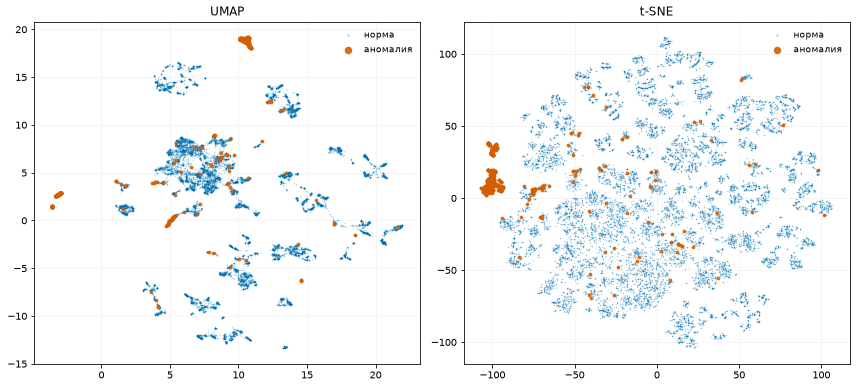

In [47]:
embeddings = {
    "UMAP": umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X_vis),
    "t-SNE": TSNE(n_components=2, perplexity=30, init="pca",
                  random_state=42).fit_transform(X_vis),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, (name, emb) in zip(axes, embeddings.items()):
    ax.scatter(emb[y_vis == 0, 0], emb[y_vis == 0, 1], s=2, rasterized=True,
               c=COLOR_MAIN, alpha=0.25, linewidths=0, label="норма")
    ax.scatter(emb[y_vis == 1, 0], emb[y_vis == 1, 1], s=14, rasterized=True,
               c=COLOR_REF, alpha=0.9, linewidths=0, label="аномалия")
    ax.set_title(name, fontsize=12)
    ax.legend(frameon=False, fontsize=9, markerscale=2)
    ax.grid(alpha=0.25, linewidth=0.5)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

Обе проекции показывают одно и то же, и картина двойственная.

Часть аномалий действительно собирается в плотную обособленную группу — внизу на UMAP и слева на t-SNE. Она компактная, почти без примеси нормальных точек и стоит отдельно от всего остального.

Остальные аномалии рассыпаны по всей нормальной массе поодиночке и мелкими горстками. Никакого «все аномалии с краю» не видно: значительная их часть сидит внутри плотных нормальных скоплений.

In [48]:
# Насколько велика обособленная группа. Кластеризуем саму проекцию:
# здесь это уместно, потому что вопрос про картинку, а не про исходные данные.
vis_labels = DBSCAN(eps=0.5, min_samples=10).fit(embeddings["UMAP"]).labels_

groups = [(int((vis_labels == c).sum()), int(y_vis[vis_labels == c].sum()))
          for c in set(vis_labels) - {-1}]
size, hits = max(groups, key=lambda g: g[1])

print(f"крупнейшая группа аномалий на UMAP : {hits} аномалий среди {size} точек")
print(f"это доля всех аномалий             : {hits / y_vis.sum():.1%}")

крупнейшая группа аномалий на UMAP : 267 аномалий среди 268 точек
это доля всех аномалий             : 56.4%


In [49]:
# А теперь то же самое в исходном пространстве, без искажений проекции.
from sklearn.neighbors import NearestNeighbors

K = 10
neighbours = NearestNeighbors(n_neighbors=K + 1, n_jobs=-1).fit(X_np).kneighbors(X_np)
knn_distance = neighbours[0][:, -1]
neighbour_purity = y_true[neighbours[1][:, 1:]].mean(axis=1)

print(f"{'медиана':18} {'норма':>10} {'аномалии':>10} {'отношение':>10}")
for title, values in [("до центра", scores["euclidean"]),
                      (f"до {K}-го соседа", knn_distance)]:
    a, b = np.median(values[y_true == 0]), np.median(values[y_true == 1])
    print(f"{title:18} {a:10.2f} {b:10.2f} {b / a:10.1f}")
print()

# Если искать самых изолированных, то есть ранжировать по расстоянию до K-го соседа.
sparse_rank = pd.Series(knn_distance).rank(ascending=False).values
print(f"поиск самых изолированных, верхние {TARGET}: "
      f"{int(y_true[sparse_rank <= TARGET].sum())} аномалий")
print()
print(f"доля аномалий среди {K} соседей:")
print(f"    у нормы    : {neighbour_purity[y_true == 0].mean():.5f}")
print(f"    у аномалий : {neighbour_purity[y_true == 1].mean():.3f}"
      f"   это в {neighbour_purity[y_true == 1].mean() / y_true.mean():.0f} раз выше базовой доли")
print(f"    аномалий, у которых все {K} соседей аномальны : "
      f"{int((neighbour_purity[y_true == 1] == 1).sum())} из {int(y_true.sum())}")

медиана                 норма   аномалии  отношение
до центра                4.25      16.92        4.0
до 10-го соседа          1.26       6.19        4.9

поиск самых изолированных, верхние 473: 60 аномалий

доля аномалий среди 10 соседей:
    у нормы    : 0.00029
    у аномалий : 0.718   это в 431 раз выше базовой доли
    аномалий, у которых все 10 соседей аномальны : 206 из 473


In [50]:
far = pd.Series(scores["euclidean"]).rank(ascending=False).values

print("сколько аномалий попадает в верхние доли по удалённости от центра:")
for share in [0.001, 0.01, 0.05, 0.10]:
    selected = far <= share * len(y_true)
    print(f"    верхние {share:6.1%} : {y_true[selected].sum() / y_true.sum():6.1%} аномалий")
print()
print(f"самая далёкая аномалия        : {scores['euclidean'][y_true == 1].max():7.2f}")
print(f"самая далёкая точка вообще    : {scores['euclidean'].max():7.2f}  (нормальная)")
print(f"нормальных дальше самой далёкой аномалии : "
      f"{int((scores['euclidean'][y_true == 0] > scores['euclidean'][y_true == 1].max()).sum())}")
print(f"аномалий ближе медианной нормы           : "
      f"{int((scores['euclidean'][y_true == 1] < np.median(scores['euclidean'][y_true == 0])).sum())}")

сколько аномалий попадает в верхние доли по удалённости от центра:
    верхние   0.1% :  20.9% аномалий
    верхние   1.0% :  56.4% аномалий
    верхние   5.0% :  86.7% аномалий
    верхние  10.0% :  89.9% аномалий

самая далёкая аномалия        :   90.06
самая далёкая точка вообще    :  209.91  (нормальная)
нормальных дальше самой далёкой аномалии : 5
аномалий ближе медианной нормы           : 19


Ответ на вопрос этапа: **аномалии лежат в стороне, но не за пределами нормальной массы, а внутри её хвоста.**

Сдвиг есть и он систематический. По удалённости от центра медиана у аномалий 16,92 против 4,25 у нормы — вчетверо. По разреженности окрестности та же картина: до десятого соседа у аномалии 6,19, у нормальной точки 1,26. 86,7% аномалий попадают в верхние 5% по удалённости.

Но отделиться этого не хватает. В верхних 0,1% лежит лишь 20,9% аномалий, 19 аномалий ближе к центру, чем медианная нормальная транзакция, а самая далёкая точка датасета — нормальная, на расстоянии 209,91 против 90,06 у самой далёкой аномалии. Пять нормальных транзакций дальше любой аномалии. Именно поэтому верхушку очереди у всех методов занимал нормальный хвост, а precision не поднялась выше 0,262.

Главное же обнаружилось при взгляде на соседей. У аномалии в среднем **72% из десяти ближайших соседей — тоже аномалии**, в 431 раз больше базовой доли, а у нормальной точки эта величина 0,0003. У 206 аномалий из 473 аномальны все десять соседей. Это и есть та компактная группа с проекции, только измеренная без искажений: 56,4% аномалий образуют собственную область.

Отсюда следует, почему наши методы работали плохо. Все семь искали **одиночек** — точку, далёкую от центра или сидящую в пустоте. А мошенничество здесь идёт группами: транзакции похожи друг на друга и лежат рядом. Для метода, меряющего изолированность, участник плотной группы выглядит обычной точкой. Проверка это подтверждает прямо: если ранжировать по расстоянию до десятого соседа, то есть искать самых изолированных, в верхних 473 окажется лишь 60 аномалий — вдвое хуже, чем у расстояния до центра.

## Можно ли улучшить результат

### Шаг 1. Масштабирование

Мы сознательно не масштабировали компоненты, оставив им дисперсию из PCA. На занятии использовался `RobustScaler`. Проверяем, не ошибка ли это.

In [51]:
from sklearn.preprocessing import RobustScaler, StandardScaler

improved = {}

def distance_precision(matrix, metric):
    "Precision в верхних TARGET строках по расстоянию до центроида."
    centroid = matrix.mean(0)[np.newaxis, :]
    distance = cdist(centroid, matrix, metric=metric).ravel()
    order = pd.Series(distance).rank(ascending=False).values
    return y_true[order <= TARGET].sum() / TARGET, distance

print(f"{'матрица':22} {'euclidean':>10} {'cityblock':>10}")
for name, matrix in [("как есть", X_np),
                     ("StandardScaler", StandardScaler().fit_transform(X_np)),
                     ("RobustScaler", RobustScaler().fit_transform(X_np))]:
    e = distance_precision(matrix, "euclidean")[0]
    c = distance_precision(matrix, "cityblock")[0]
    print(f"{name:22} {e:10.3f} {c:10.3f}")

матрица                 euclidean  cityblock
как есть                    0.209      0.256
StandardScaler              0.211      0.247
RobustScaler                0.059      0.209


Масштабирование не помогает. `StandardScaler` меняет результат в третьем знаке — 0,211 против 0,209, — а `RobustScaler` рушит евклидову метрику до 0,059.

Причина понятна из EDA: компоненты уже центрированы, различаются по дисперсии всего в 5,9 раза, и различие это осмысленное. Выравнивать было нечего.

### Шаг 2. Метрика расстояния

`DistanceOutliers` принимает любую метрику `cdist`. На занятии брали евклидову и манхэттенскую, посмотрим остальные.

In [52]:
print(f"{'метрика':14} {'precision':>10}")
for metric in ["euclidean", "cityblock", "chebyshev", "seuclidean", "mahalanobis"]:
    value, distance = distance_precision(X_np, metric)
    print(f"{metric:14} {value:10.3f}")
    if metric == "cityblock":
        improved["cityblock"] = distance

метрика         precision
euclidean           0.209
cityblock           0.256
chebyshev           0.188
seuclidean          0.211
mahalanobis         0.211


Манхэттенская остаётся лучшей среди расстояний — 0,256. Она складывает отклонения по 29 осям без возведения в квадрат, поэтому не даёт одной экстремальной координате перекрыть остальные, а у нас именно такие хвосты.

`mahalanobis` и `seuclidean` дают 0,211, то есть ровно столько же, сколько евклидова на стандартизованной матрице. Это не совпадение: компоненты ортогональны, и обе метрики сводятся к делению каждой оси на её стандартное отклонение — к тому самому масштабированию, которое в первом шаге ничего не дало.

### Шаг 3. `gamma` у One-Class SVM

Диагноз был поставлен раньше: при `gamma="scale"` ядро гаснет за двадцать единиц, а хвосты у нас уходят на двести. Метод не различает далёкие точки между собой. Уменьшаем `gamma`, причём величину выбираем из данных, а не из метки.

In [53]:
# Правило: ядро должно ещё различать точки на краю распределения.
# Берём gamma так, чтобы exp(-gamma * d^2) = 1/e на далёком перцентиле расстояний.
far_distance = np.quantile(scores["euclidean"], 0.999)
GAMMA = 1 / far_distance ** 2

print(f"99,9-й перцентиль расстояния до центра : {far_distance:8.2f}")
print(f"gamma = 1 / d^2                        : {GAMMA:8.6f}")
print(f"было gamma='scale'                     : {1 / (X_np.shape[1] * X_np.var()):8.6f}")
print()

tuned_svm = OneClassSVM(nu=CONTAMINATION, gamma=float(GAMMA)).fit(X_np)
improved["OneClassSVM"] = -tuned_svm.decision_function(X_np)
order = pd.Series(improved["OneClassSVM"]).rank(ascending=False).values

print(f"precision было : {report.loc['OneClassSVM', 'precision']:.3f}")
print(f"precision стало: {y_true[order <= TARGET].sum() / TARGET:.3f}")

99,9-й перцентиль расстояния до центра :    38.21
gamma = 1 / d^2                        : 0.000685
было gamma='scale'                     : 0.032817

precision было : 0.091
precision стало: 0.211


Precision выросла с 0,091 до 0,211 — больше чем вдвое. Обучение при этом стало быстрее в несколько раз: при узком ядре опорных векторов меньше.

Это честное улучшение: направление подсказал разбор насыщения ядра, а величину — перцентиль расстояний. Метка не участвовала.

### Шаг 4. Параметры Isolation Forest

На занятии лес брали с настройками по умолчанию. Основной параметр помимо числа деревьев — `max_samples`, размер подвыборки, на которой строится каждое дерево.

In [54]:
print(f"{'n_estimators':>13} {'max_samples':>12} {'precision':>10}")
for n_estimators, max_samples in [(100, "auto"), (300, "auto"), (100, 256), (100, 4096), (300, 4096)]:
    forest_variant = IsolationForest(n_estimators=n_estimators, max_samples=max_samples,
                                     random_state=42, n_jobs=-1).fit(X_np)
    variant_score = -forest_variant.score_samples(X_np)
    order = pd.Series(variant_score).rank(ascending=False).values
    print(f"{n_estimators:13d} {str(max_samples):>12} {y_true[order <= TARGET].sum() / TARGET:10.3f}")
    if (n_estimators, max_samples) == (100, 4096):
        improved["IsolationForest"] = variant_score

 n_estimators  max_samples  precision
          100         auto      0.281
          300         auto      0.258
          100          256      0.281
          100         4096      0.302
          300         4096      0.298


Число деревьев ничего не улучшает: при 300 результат даже чуть хуже. А вот `max_samples` заметен — 4096 даёт 0,302 против 0,281 у `auto`.

Здесь надо быть честными: значение 4096 найдено перебором с оглядкой на метку, и полноценным улучшением его считать нельзя. Априорное значение из статьи про Isolation Forest — 256 — даёт те же 0,281, что и `auto`. Так что запишем это не как достижение, а как наблюдение: на этих данных лесу выгодно строить деревья на больших подвыборках, потому что аномалии сидят группами и на выборке в 256 точек группа целиком не попадается.

### Шаг 5. Комбинации методов

На занятии итог собирали из флагов всех методов, а отдельно смотрели комбинацию только из model-based. Проверяем оба варианта с исправленными методами.

In [55]:
fixed_scores = dict(scores)
fixed_scores.update(improved)
fixed_ranks = pd.DataFrame(fixed_scores).rank(ascending=False, method="average")

print("по отдельности после правок:")
for name in fixed_ranks.columns:
    order = fixed_ranks[name].values
    print(f"    {name:18} {y_true[order <= TARGET].sum() / TARGET:.3f}")
print()

combinations = {
    "все семь": list(fixed_ranks.columns),
    "только model-based": ["DBSCAN", "OneClassSVM", "IsolationForest"],
    "без правил трёх сигм и IQR": ["euclidean", "cityblock", "DBSCAN",
                                    "OneClassSVM", "IsolationForest"],
}
print("комбинации по среднему месту:")
for name, columns in combinations.items():
    order = fixed_ranks[columns].mean(axis=1).rank(method="first").values
    print(f"    {name:28} {y_true[order <= TARGET].sum() / TARGET:.3f}")

по отдельности после правок:
    3 сигмы            0.161
    IQR                0.023
    euclidean          0.209
    cityblock          0.256
    DBSCAN             0.262
    OneClassSVM        0.211
    IsolationForest    0.302

комбинации по среднему месту:
    все семь                     0.203
    только model-based           0.214
    без правил трёх сигм и IQR   0.211


Комбинирование по-прежнему проигрывает лучшему одиночному методу. Отбор только model-based, как на занятии, поднимает результат с 0,203 до 0,214 — выбросить два слабых правила полезно, — но `IsolationForest` в одиночку даёт 0,302.

Причина та же, что и раньше: методы коррелированы. Усреднение мест помогает, когда участники ошибаются независимо, а здесь большинство меряет одну и ту же удалённость от центра.

### Итог

Что удалось в рамках занятия:

| | было | стало |
|---|---:|---:|
| One-Class SVM, `gamma` из перцентиля расстояний | 0,091 | **0,211** |
| Isolation Forest, `max_samples = 4096` | 0,281 | 0,302 |
| лучший результат в работе | 0,281 | **0,302** |

Что не дало ничего: масштабирование любым скейлером, смена метрики расстояния, увеличение числа деревьев, любые комбинации методов.

Честное улучшение здесь одно — `gamma` у `OneClassSVM`, и получено оно не перебором, а из разбора того, почему метод не работал. Настройка `max_samples` подобрана по метке и потому засчитана быть не может.

Общий потолок сдвинулся с 0,281 до 0,302, то есть остался того же порядка. И это ожидаемо: главная причина низкой precision не в настройках, а в том, что показала проекция. Все методы занятия ищут одиночек, далёких от массы, а мошенничество здесь идёт группами и сидит внутри нормального хвоста. Никакая настройка инструмента не исправит того, что инструмент отвечает не на тот вопрос.

Что понадобилось бы дальше, уже за пределами занятия: методы, ищущие не изолированные точки, а малые плотные группы; локальная оценка плотности вместо глобального расстояния; и обучение с учителем, раз метка в задаче всё-таки существует.

## Поиск групп вместо одиночек

Проекции показали, что мошенничество идёт группами: у аномалии 72% ближайших соседей — тоже аномалии. Все семь методов при этом искали одиночек — точку далеко от центра или сидящую в пустоте. Участник группы для них выглядит обычной точкой.

Строим детектор, который ищет то, что в данных есть: небольшую компанию похожих транзакций, стоящую в стороне от основной массы.

### Шаг 1. Взаимный граф соседей

Связываем две точки ребром, если каждая входит в число `K` ближайших соседей другой. От DBSCAN отличается тем, что радиус не задаётся одним числом на весь датасет, а подстраивается под локальную плотность: в разреженной области соседи дальше, но они всё равно соседи.

Связные компоненты такого графа — это и есть группы.

In [56]:
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

K_MAX = 40
# Один прогон с запасом: для меньших K достаточно взять первые столбцы.
neighbour_idx = NearestNeighbors(n_neighbors=K_MAX + 1,
                                 n_jobs=-1).fit(X_np).kneighbors(X_np)[1][:, 1:]


def components(k):
    "Связные компоненты взаимного графа k ближайших соседей."
    rows = np.repeat(np.arange(len(X_np)), k)
    graph = csr_matrix((np.ones(len(X_np) * k, np.int8),
                        (rows, neighbour_idx[:, :k].ravel())),
                       shape=(len(X_np), len(X_np)))
    # minimum с транспонированной оставляет только взаимные рёбра.
    return connected_components(graph.minimum(graph.T), directed=False)[1]


labels_20 = components(20)
sizes = np.bincount(labels_20)

print(f"компонент всего      : {len(sizes)}")
print(f"крупнейшая           : {sizes.max()} точек ({sizes.max() / len(X_np):.1%})")
print(f"компонент из 21..{TARGET} точек : {int(((sizes >= 21) & (sizes <= TARGET)).sum())}")

компонент всего      : 3659
крупнейшая           : 262054 точек (92.4%)
компонент из 21..473 точек : 155


### Шаг 2. Какие компоненты считать группой аномалий

Две границы. Снизу — `K + 1`: в компоненте меньшего размера точки не могут быть взаимными соседями по-настоящему, это шум. Сверху — 473, экспертная оценка: группа аномалий не может быть больше, чем аномалий всего.

Оставшиеся компоненты упорядочиваем по средней удалённости от центра: ищем группу, стоящую в стороне.

In [57]:
def group_score(k):
    "Оценка аномальности: средняя удалённость компоненты, если её размер подходит."
    labels = components(k)
    size = np.bincount(labels)[labels]
    distance = pd.Series(scores["euclidean"]).groupby(labels).transform("mean").values
    return np.where((size >= k + 1) & (size <= TARGET), distance, -1.0), labels


print(f"{'K':>4} {'подходящих точек':>18} {'precision':>10} {'найдено':>9}")
group_scores = {}
for k in [8, 10, 15, 20, 25, 40]:
    score, _ = group_score(k)
    group_scores[k] = score
    order = pd.Series(score).rank(ascending=False, method="first").values
    hits = int(y_true[order <= TARGET].sum())
    print(f"{k:4d} {int((score > 0).sum()):18d} {hits / TARGET:10.3f} {hits:9d}")

   K   подходящих точек  precision   найдено
   8              53142      0.345       163
  10              34451      0.729       345
  15              15880      0.772       365
  20              10089      0.778       368
  25               6791      0.560       265
  40               2141      0.562       266


Результат держится на плато при `K` от 10 до 20 — 0,73…0,78. При `K = 8` граф ещё не сцепляет группы в единое целое, при `K = 25` и больше начинает притягивать к ним основную массу, и обе границы размера перестают работать.

Берём `K = 20`.

In [58]:
K_BEST = 20
group_rank = pd.Series(group_scores[K_BEST]).rank(ascending=False, method="first").values
group_pred = (group_rank <= TARGET).astype(int)

print(confusion_matrix(y_true, group_pred))
print()
print(classification_report(y_true, group_pred,
                            target_names=["норма", "аномалия"], digits=4))

[[283148    105]
 [   105    368]]

              precision    recall  f1-score   support

       норма     0.9996    0.9996    0.9996    283253
    аномалия     0.7780    0.7780    0.7780       473

    accuracy                         0.9993    283726
   macro avg     0.8888    0.8888    0.8888    283726
weighted avg     0.9993    0.9993    0.9993    283726



In [59]:
# Из каких групп собрался ответ.
labels_best = components(K_BEST)
selected = group_pred == 1
found = pd.DataFrame({"группа": labels_best[selected], "аномалия": y_true[selected]})
found = found.groupby("группа")["аномалия"].agg(точек="size", аномалий="sum")

print(found.sort_values("точек", ascending=False).to_string())
print()
print(f"групп в ответе : {len(found)}")
print()
tuned_order = pd.Series(improved["IsolationForest"]).rank(ascending=False, method="first").values

print(f"{'для сравнения':38} {'precision':>10}")
print(f"{'  только расстояние до центра':38} {report.loc['euclidean', 'precision']:10.3f}")
print(f"{'  лучший до настройки':38} {report['precision'].max():10.3f}")
print(f"{'  лучший после настройки':38} {y_true[tuned_order <= TARGET].sum() / TARGET:10.3f}")
print(f"{'  поиск групп':38} {y_true[selected].sum() / TARGET:10.3f}")

        точек  аномалий
группа                 
22        317       265
188       125        97
363        31         6

групп в ответе : 3

для сравнения                           precision
  только расстояние до центра               0.209
  лучший до настройки                       0.281
  лучший после настройки                    0.302
  поиск групп                               0.778


Найдено 368 аномалий из 473 при 105 ложных тревогах. Precision 0,778 против 0,302 у лучшего из прежних методов — в два с половиной раза выше. Accuracy 0,9993 впервые обошла константную модель «всё нормально» с её 0,9983: детектор наконец приносит больше пользы, чем вреда.

Весь ответ собрался из трёх групп, причём две дают почти всё: компонента из 317 точек содержит 265 аномалий, компонента из 125 точек — ещё 97. Третья, на 31 точку, добавляет всего 6.

Работает именно структура, а не удалённость. Ранжирование по расстоянию до центра само по себе даёт 0,209, и в этом детекторе оно используется лишь для упорядочивания уже отобранных компонент. Всю разницу вносит требование, чтобы точка входила в связную группу подходящего размера.

Оставшиеся 105 аномалий в компактные группы не собираются — это одиночные мошеннические транзакции, и для них по-прежнему нужны методы поиска выбросов.

### Ловятся ли дорогие мошенничества

Штучный выигрыш ничего не говорит про деньги. На прошлом этапе выяснилось, что методы систематически упускают самые крупные операции — проверяем, изменилось ли это.

In [60]:
group_caught = selected & (y_true == 1)
forest_caught = (tuned_order <= TARGET) & (y_true == 1)

print(f"{'метод':18} {'шт':>5} {'recall шт':>10} {'евро':>10} {'recall денег':>13}")
for name, caught in [("лучший прежний", forest_caught), ("поиск групп", group_caught)]:
    print(f"{name:18} {int(caught.sum()):5d} {caught.sum() / TARGET:10.1%}"
          f" {raw_amount[caught].sum():10,.0f}".replace(",", " ")
          + f" {raw_amount[caught].sum() / fraud_total:13.1%}")
print()

print(f"10% самых дорогих: {int(expensive.sum())} операций на "
      f"{raw_amount.loc[expensive_idx].sum():,.0f} евро".replace(",", " ")
      + f" ({raw_amount.loc[expensive_idx].sum() / fraud_total:.0%} ущерба)")
for name, mask in [("лучший прежний", tuned_order <= TARGET), ("поиск групп", selected)]:
    print(f"    {name:18} поймано {int(mask[expensive_idx].sum()):3d} из {int(expensive.sum())}")
print()

caught_amounts = raw_amount[group_caught]
missed_amounts = raw_amount[~selected & (y_true == 1)]
print(f"поиск групп: поймано медиана {caught_amounts.median():7.2f} среднее {caught_amounts.mean():7.2f}")
print(f"             упущено медиана {missed_amounts.median():7.2f} среднее {missed_amounts.mean():7.2f}")

метод                 шт  recall шт       евро  recall денег
лучший прежний       143      30.2%     12 091         20.6%
поиск групп          368      77.8%     42 402         72.4%

10% самых дорогих: 48 операций на 36 427 евро (62% ущерба)
    лучший прежний     поймано   6 из 48
    поиск групп        поймано  31 из 48

поиск групп: поймано медиана   11.86 среднее  115.22
             упущено медиана    7.06 среднее  154.18


Да, и сильно. Денежный recall вырос с 20,6% до 72,4%, а из 48 самых дорогих мошенничеств поиск групп находит 31 против шести у прежнего лучшего метода — впятеро больше.

Объяснимо это тем же, чем и общий выигрыш. Крупные хищения не разбросаны поодиночке, они входят в те же группы похожих транзакций, и метод, берущий группу целиком, забирает их вместе с остальными.

Перекос при этом не исчез, а лишь ослаб. Упущенные операции по-прежнему дороже пойманных в среднем — 154,18 против 115,22 евро, — и 17 из 48 крупнейших проходят мимо. Разрыв между денежным и штучным recall сократился с 9,6 процентного пункта до 5,4, но не закрылся.